# Colab Setup !

*   Laufzeittyp: Python 3
*   Hardwarebeschleuniger: T4 GPU
*   Laufzeitversion: 2026.07

Run with Python 3.12 in Colab.

Colab's Python (3.13) does not match expected version: 3.12.

Notwendig:

*   Reading times values from BSPR (010826_results_prod.csv)
*   Sentences,Words,CS values that is used in BSPR (word_cs.xlsx)
*   CS Korpus (TuGeBiC_Twitter_TRDE.csv)
*   CS_Punkte_TR (if available -pass first Block)





# SET-UP

In [ ]:
!pip install -q condacolab
import condacolab
condacolab.install()

⏬ Downloading https://github.com/conda-forge/miniforge/releases/download/25.11.0-1/Miniforge3-25.11.0-1-Linux-x86_64.sh...
📦 Installing...
📌 Adjusting configuration...
🩹 Patching environment...
⏲ Done in 0:00:19
🔁 Restarting kernel...


In [ ]:
!mamba install -q pymer4 rpy2 -c ejolly -c conda-forge

warning  libmamba [numpy-2.5.2-py312he827f4e_1] The following files were already present in the environment:
    - bin/f2py
    - bin/numpy-config
warning  libmamba [babel-2.18.0-pyhcf101f3_1] The following files were already present in the environment:
    - bin/pybabel
warning  libmamba [r-base-4.5.2-h835929b_2] The following files were already present in the environment:
    - bin/R


In [ ]:
# Lösche die vorinstallierte ALTE rpy2-Kopie von Colab manuell
!rm -rf /usr/local/lib/python3.12/dist-packages/rpy2*
!rm -rf /usr/local/lib/python3.12/dist-packages/_rinterface_cffi*
# Kontrolle
!ls -d /usr/local/lib/python3.12/dist-packages/rpy2 2>/dev/null && echo
!ls -d /usr/local/lib/python3.12/site-packages/rpy2 2>/dev/null && echo


/usr/local/lib/python3.12/site-packages/rpy2



In [ ]:
# Runtime ERNEUT starten (das Löschen entfernt die von Python
# im Speicher gehaltenen Referenzen nicht, ein neuer Prozess ist erforderlich)
import os
os.kill(os.getpid(), 9)

In [ ]:
# NACH dem zweiten Neustart überprüfen
import rpy2
import importlib.metadata
import pandas as pd
import numpy as np
import polars as pl
from pymer4.models import lmer

print("rpy2 versiyon:", importlib.metadata.version("rpy2"))

np.random.seed(0)
rows = [{"subj": f"S{s}", "item": f"I{i}",
         "x": np.random.randn(), "y": np.random.randn()}
        for s in range(10) for i in range(8)]
test_df_pd = pd.DataFrame(rows)
test_df_pl = pl.from_pandas(test_df_pd)  # pymer4 0.9.x expects polars, not pandas

test_model = lmer("y ~ x + (1|subj) + (1|item)", data=test_df_pl)
test_model.fit()
print(test_model.params)
print("\nERFOLGREICH - LMER kann ausgeführt werden.")

rpy2 versiyon: 3.6.7
R messages: 
boundary (singular) fit: see help('isSingular')

Random effect variances not available. Returned R2 does not account for random effects.

R messages: 
boundary (singular) fit: see help('isSingular')

Random effect variances not available. Returned R2 does not account for random effects.

shape: (2, 2)
┌─────────────┬───────────┐
│ term        ┆ estimate  │
│ ---         ┆ ---       │
│ str         ┆ f64       │
╞═════════════╪═══════════╡
│ (Intercept) ┆ 0.194841  │
│ x           ┆ -0.093479 │
└─────────────┴───────────┘

ERFOLGREICH - LMER kann ausgeführt werden.


# GENERAL CORPUS FEATURES

# Utils for scripts

In [ ]:
!pip install -q polars statsmodels seaborn

In [ ]:
!pip install -q deep-translator openpyxl
!pip install -q git+https://github.com/apakabarfm/syllabreak-python.git

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [ ]:
%%writefile utils_cs.py

Writing utils_cs.py


In [ ]:
"""
utils_cs.py
===========

Gemeinsame Funktionen und Pfade für alle Analyseskripte. Damit importiert
kein Skript mehr aus einem anderen Skript; alles Geteilte liegt hier.

Ausgelegt auf Google Colab. Alle Pfade liegen fest unter /content:

    /content                 Eingabedateien (CSV, XLSX)
    /content/Bspr_result     erzeugte CSV-Dateien
    /content/Grafik          Grafiken

Verwendung -- erste Zelle schreibt diese Datei auf die Festplatte:

    %%writefile utils_cs.py
    <Inhalt dieser Datei>

Zweite Zelle:

    from utils_cs import *
    show_paths(); show_pipeline()

Danach kann jedes weitere Skript unverändert in eine eigene Zelle eingefügt
werden.
"""

from pathlib import Path
from functools import lru_cache
import sys

import pandas as pd

# ----------------------------------------------------------------------
# Pfade -- fest auf Colab eingestellt
# ----------------------------------------------------------------------
BASE_DIR = Path("/content")            # Eingabedateien
OUT_DIR = BASE_DIR / "Bspr_result"     # erzeugte CSV-Dateien
PLOT_DIR = BASE_DIR / "Grafik"         # Grafiken
DATA_DIR = BASE_DIR                    # Alias, für ältere Aufrufe

OUT_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR.mkdir(parents=True, exist_ok=True)

if str(BASE_DIR) not in sys.path:
    sys.path.insert(0, str(BASE_DIR))


def find_file(name: str) -> Path:
    """
    Eine Datei zuerst in /content, dann in /content/Bspr_result suchen.
    """
    for path in (BASE_DIR / name, OUT_DIR / name):
        if path.exists():
            return path
    raise FileNotFoundError(
        f"'{name}' wurde nicht gefunden. Geprüft wurde:\n"
        f"  {BASE_DIR / name}\n"
        f"  {OUT_DIR / name}\n"
        f"Bitte die Datei nach /content hochladen."
    )


def show_paths() -> None:
    print(f"Eingabedaten : {BASE_DIR}")
    print(f"Ergebnisse   : {OUT_DIR}")
    print(f"Grafiken     : {PLOT_DIR}")


# ----------------------------------------------------------------------
# Übersetzung (deep-translator)
# ----------------------------------------------------------------------
@lru_cache(maxsize=10000)
def translate_cached(text: str, src: str, dest: str) -> str:
    """
    Translate a single text using deep_translator.GoogleTranslator, with LRU caching.
    """
    from deep_translator import GoogleTranslator
    try:
        translator = GoogleTranslator(source=src or "auto", target=dest)
        return translator.translate(text)
    except Exception as e:
        print(f"Übersetzungsfehler: {text[:20]}... -> {e}")
        return text


def translate(text: str, src: str, dest: str) -> str:
    """
    Safe wrapper around translate_cached with input validation and trimming.
    """
    if not text:
        return text
    if not isinstance(text, str):
        text = str(text)
    text = text.strip()
    if not text:
        return text
    return translate_cached(text, src, dest)


# ----------------------------------------------------------------------
# Silbenzählung
# ----------------------------------------------------------------------
_syllabreaker = None


def _get_syllabreaker():
    global _syllabreaker
    if _syllabreaker is None:
        from syllabreak import Syllabreak
        _syllabreaker = Syllabreak("-")
    return _syllabreaker


def count_syllables(word: str, lang: str) -> int:
    """
    Count syllables for a word in supported languages using syllabreaker.
    """
    if not isinstance(word, str) or not word.strip():
        return 0

    word = word.strip()
    lang_map = {"TR": "tur", "DE": "deu"}
    code = lang_map.get(lang.upper())

    if not code:
        print(f"Warning: Unknown language '{lang}' — skipping syllable count.")
        return 0

    try:
        hyphenated = _get_syllabreaker().syllabify(word, lang=code)
        return len(hyphenated.split("-"))
    except Exception as e:
        print(f"Warning: Could not syllabify '{word}' ({lang}): {e}")
        return 1


# ----------------------------------------------------------------------
# Kürzere Sprachoption bestimmen
# ----------------------------------------------------------------------
def compute_kurz_silben(tr_s, de_s):
    """
    Compute which language(s) yield the fewest syllables for a given word (TR, DE, TR/DE).
    """
    vals = {"TR": tr_s, "DE": de_s}
    valid = {k: v for k, v in vals.items() if v is not None}
    if not valid:
        return ""
    try:
        min_val = min(valid.values())
    except Exception:
        valid = {k: int(v) for k, v in valid.items() if str(v).isdigit()}
        if not valid:
            return ""
        min_val = min(valid.values())
    return "/".join(k for k in ["TR", "DE"] if valid.get(k) == min_val)


def compute_kurz_len(tr_len, de_len):
    """
    Compute which language(s) yield the shortest string length for a given word (TR, DE, TR/DE).
    """
    lengths = {"TR": tr_len, "DE": de_len}
    valid = {k: v for k, v in lengths.items() if v is not None}
    if not valid:
        return ""
    min_len = min(valid.values())
    return "/".join([lang for lang, val in valid.items() if val == min_len])


# ----------------------------------------------------------------------
# Code-Switching-Spalte
# ----------------------------------------------------------------------
def add_cs_columns(df: pd.DataFrame, force: bool = False) -> pd.DataFrame:
    """
    Adds or recomputes the 'CS' column in the DataFrame.

    A word is marked as a CS point (1) when its language differs from that of
    the IMMEDIATELY PRECEDING word within the same sentence. Words labelled
    OTHER are never marked as CS points, and a word directly following an
    OTHER token is not marked either.
    """
    df_copy = df.copy().reset_index(drop=True)
    if force or "CS" not in df_copy.columns:
        df_copy["CS"] = [
            int(
                i > 0
                and df_copy.loc[i, "ID"] == df_copy.loc[i - 1, "ID"]
                and df_copy.loc[i, "LANG"] != df_copy.loc[i - 1, "LANG"]
                and df_copy.loc[i, "LANG"] != "OTHER"
                and df_copy.loc[i - 1, "LANG"] != "OTHER"
            )
            for i in range(len(df_copy))
        ]
    return df_copy


def report_switches_hidden_by_other(df: pd.DataFrame) -> None:
    """
    Diagnostic only -- does not change the CS column. Counts language switches
    that are not registered as CS points because one or more OTHER tokens sit
    between the two words of different languages.
    """
    if not {"ID", "LANG"}.issubset(df.columns):
        return

    hidden = 0
    for _, g in df.groupby("ID", sort=False):
        last_real = None
        gap_since_last = False
        for lang in g["LANG"].tolist():
            if lang == "OTHER":
                if last_real is not None:
                    gap_since_last = True
                continue
            if last_real is not None and lang != last_real and gap_since_last:
                hidden += 1
            last_real = lang
            gap_since_last = False

    print(f"Sprachwechsel, die durch dazwischenliegende OTHER-Token nicht als "
          f"CS-Punkt erfasst wurden: {hidden}")
    print(" ")


# ----------------------------------------------------------------------
# Allgemeine Längen- und Silbenstatistik
# ----------------------------------------------------------------------
def calculate_general_length_stats(df, sample_size=None):
    df_clean = df.copy()
    df_clean["WORD_LEN"] = df_clean["WORD"].astype(str).apply(len)
    if sample_size:
        try:
            df_clean = df_clean.groupby(["LANG", "POS"]).apply(
                lambda x: x.sample(n=min(len(x), sample_size), random_state=42)
            ).reset_index(drop=True)
        except Exception as e:
            print(f"An error occurred while sampling, all data is being used: {e}")
    stats = df_clean.groupby(["LANG", "POS"])["WORD_LEN"].mean().reset_index()
    stats.rename(columns={"WORD_LEN": "AVG_LENGTH"}, inplace=True)
    return stats.sort_values(by=["POS", "LANG"])


def calculate_general_syllable_stats(df, sample_size=None):
    df_clean = df.copy()
    valid_langs = ["TR", "DE", "ENG"]
    df_clean = df_clean[df_clean["LANG"].str.upper().isin(valid_langs)]

    df_clean["SYLLABLE_COUNT"] = df_clean.apply(
        lambda row: count_syllables(str(row["WORD"]), str(row["LANG"])), axis=1
    )
    if sample_size:
        try:
            df_clean = df_clean.groupby(["LANG", "POS"]).apply(
                lambda x: x.sample(n=min(len(x), sample_size), random_state=42)
            ).reset_index(drop=True)
        except Exception as e:
            print(f"An error occurred while sampling, all data is being used: {e}")
    stats = df_clean.groupby(["LANG", "POS"])["SYLLABLE_COUNT"].mean().reset_index()
    stats.rename(columns={"SYLLABLE_COUNT": "AVG_SYLLABLES"}, inplace=True)
    return stats.sort_values(by=["POS", "LANG"])


# ----------------------------------------------------------------------
# Kleine Hilfen
# ----------------------------------------------------------------------
def load_data(path) -> pd.DataFrame:
    return pd.read_csv(path)


def save_data(df: pd.DataFrame, path) -> None:
    df.to_csv(path, index=False)


# Reihenfolge der Skripte, falls man sie nachschlagen will.
PIPELINE_ORDER = [
    "a_cs_features_tr.py          -- CS-Punkte-Datenrahmen (Übersetzung, Länge, Silben)",
    "b_cs_corpus_overview_tr.py   -- Korpusübersicht, legt die Spalte CS an",
    "c_cs_res_tr.py               -- Quantitative Analyse (GLR, GSR, Korrelationen)",
    "d_clean_bspr_data.py         -- BSPR-Rohdaten bereinigen",
    "g_XGLM_surprisal_values.py   -- Surprisal mit XGLM-1.7B",
    "i_XGLM_564M_surprisal_values.py -- Surprisal mit XGLM-564M",
    "h_Lmem_Surprisal.py          -- LMEM-Hauptanalyse",
    "j_Lmem_Modellvergleich.py    -- Modellvergleich der beiden Sprachmodelle",
    "e_surprisal_rt_sample.py     -- Grafik: einzelner Satz",
    "f_surprisal_rt_all_sample.py -- Grafiken: alle Sätze im Raster",
]


def show_pipeline() -> None:
    for i, step in enumerate(PIPELINE_ORDER, 1):
        print(f"{i:2d}. {step}")


if __name__ == "__main__":
    show_paths()
    print()
    show_pipeline()

Eingabedaten : /content
Ergebnisse   : /content/Bspr_result
Grafiken     : /content/Grafik

 1. a_cs_features_tr.py          -- CS-Punkte-Datenrahmen (Übersetzung, Länge, Silben)
 2. b_cs_corpus_overview_tr.py   -- Korpusübersicht, legt die Spalte CS an
 3. c_cs_res_tr.py               -- Quantitative Analyse (GLR, GSR, Korrelationen)
 4. d_clean_bspr_data.py         -- BSPR-Rohdaten bereinigen
 5. g_XGLM_surprisal_values.py   -- Surprisal mit XGLM-1.7B
 6. i_XGLM_564M_surprisal_values.py -- Surprisal mit XGLM-564M
 7. h_Lmem_Surprisal.py          -- LMEM-Hauptanalyse
 8. j_Lmem_Modellvergleich.py    -- Modellvergleich der beiden Sprachmodelle
 9. e_surprisal_rt_sample.py     -- Grafik: einzelner Satz
10. f_surprisal_rt_all_sample.py -- Grafiken: alle Sätze im Raster


# 1) Creates CS_Punkte_TR for Analyse

**Falls bereits eine CS_Punkte-Datei existiert, führen Sie diese nicht aus.**

*   (Tranlatations, Lengths, Silben, Kurz_Len, Kurz_Silben)
*   Dauert min. 1 Std. wegen der Übersetzungen
---
*   Eingabe: "TuGeBiC_Twitter_TRDE.csv"
*   Ausgabe: "CS_Punkte_TR22.csv"




Die Übersetzungen wurden automatisch über die Bibliothek deep-translator (Google Translate) erstellt. Da es sich um einen externen Dienst handelt, ist das Ergebnis nicht vollständig reproduzierbar; der für diese Arbeit verwendete Datensatz wurde am 01.08.2026 erzeugt und liegt der Arbeit bei.

In [ ]:
"""
Berechnet Wortmerkmale an Code-Switching-Punkten im Sprachpaar Türkisch-Deutsch.

Ablauf: CSV einlesen -> nur CS-Zeilen (CS == 1) -> jedes Wort in die jeweils andere
Sprache übersetzen -> Zeichenlänge und Silbenzahl bestimmen -> vergleichen, welche
Sprache kürzer ist. Die Zeilen werden parallel verarbeitet (ThreadPoolExecutor).

Eingabe:  CSV mit den Spalten ID, WORD, LANG, CS
Ausgabe:  CSV mit Übersetzungen, Längen, Silbenzahlen sowie KURZ_LEN und
          KURZ_SILBEN ('TR', 'DE' oder 'TR/DE' bei Gleichstand)
"""

import os
import time
from functools import lru_cache
from concurrent.futures import ThreadPoolExecutor, as_completed

import pandas as pd
from syllabreak import Syllabreak
from deep_translator import GoogleTranslator

# Spaltenkürzel -> Sprachcode für Übersetzer bzw. Silbentrennung
LANGS = {'DE': 'de', 'TR': 'tr'}
SYLL_CODES = {'DE': 'deu', 'TR': 'tur'}

COLS = ['ID', 'WORD', 'LANG',
        'DE', 'DE_LEN', 'DE_SILBEN',
        'TR', 'TR_LEN', 'TR_SILBEN',
        'KURZ_LEN', 'KURZ_SILBEN']

_syllabreaker = Syllabreak("-")


# Übersetzung
@lru_cache(maxsize=10000)
def _translate_cached(text: str, src: str, dest: str) -> str:
    """Übersetzt einen Text; bei Fehlern bleibt das Original stehen."""
    try:
        return GoogleTranslator(source=src or 'auto', target=dest).translate(text)
    except Exception as e:
        print(f"Übersetzungsfehler: {text[:20]}... -> {e}")
        return text


def translate(text: str, src: str, dest: str) -> str:
    """Prüft die Eingabe und ruft die gecachte Übersetzung auf."""
    if not text:
        return text
    text = str(text).strip()
    return _translate_cached(text, src, dest) if text else text


# Silbenzählung
def count_syllables(word: str, lang: str) -> int:
    """Zählt die Silben eines Wortes; 0 bei leerer Eingabe oder unbekannter Sprache."""
    if not isinstance(word, str) or not word.strip():
        return 0

    code = SYLL_CODES.get(lang.upper())
    if not code:
        print(f"Warnung: Unbekannte Sprache '{lang}' — Silben werden nicht gezählt.")
        return 0

    try:
        return len(_syllabreaker.syllabify(word.strip(), lang=code).split("-"))
    except Exception as e:
        print(f"Warnung: '{word}' ({lang}) nicht trennbar: {e}")
        return 1


# Vergleich
def kuerzeste(tr_val, de_val) -> str:
    """Gibt die Sprache mit dem kleineren Wert zurück: 'TR', 'DE' oder 'TR/DE'."""
    vals = {k: v for k, v in (('TR', tr_val), ('DE', de_val)) if v is not None}
    if not vals:
        return ''
    min_val = min(vals.values())
    return '/'.join(k for k in ('TR', 'DE') if vals.get(k) == min_val)


# Verarbeitung
def process_row(row: pd.Series) -> list:
    """Bildet aus einer Eingabezeile eine Ergebniszeile gemäß COLS."""
    word, lang, word_id = row['WORD'], row['LANG'], row['ID']
    src = LANGS.get(lang.upper(), 'auto')

    # Bei LANG == 'TR' oder 'DE' bleibt das Wort in seiner Ausgangssprache stehen.
    # Alle anderen Werte (z. B. MIXED, LANG3) werden per Autoerkennung des Quelltexts
    # in beide Sprachen übersetzt und in beide Spaltenpaare geschrieben.
    trans = {l: word if l == lang else translate(word, src, code)
             for l, code in LANGS.items()}
    if lang in LANGS:
        trans[lang] = word

    lengths = {l: len(str(trans[l])) for l in LANGS}
    syllables = {l: count_syllables(trans[l], l) for l in LANGS}

    return [word_id, word, lang,
            trans['DE'], lengths['DE'], syllables['DE'],
            trans['TR'], lengths['TR'], syllables['TR'],
            kuerzeste(lengths['TR'], lengths['DE']),
            kuerzeste(syllables['TR'], syllables['DE'])]


def build_dataframe(df: pd.DataFrame, max_workers: int = 10) -> pd.DataFrame:
    """Verarbeitet alle Zeilen parallel und meldet den Fortschritt."""
    data = []
    total = len(df)
    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        futures = [executor.submit(process_row, row) for _, row in df.iterrows()]
        for idx, future in enumerate(as_completed(futures), 1):
            try:
                data.append(future.result())
                if idx % 50 == 0 or idx == total:
                    print(f" Verarbeitet: {idx}/{total} ({idx * 100 // total}%)")
            except Exception as e:
                print(f"  ✗ Zeilenfehler: {e}")

    return pd.DataFrame(data, columns=COLS)


def main(input_csv: str, output_csv: str):
    """Liest die CSV, verarbeitet die CS-Zeilen und schreibt das Ergebnis."""
    start = time.time()
    cs_rows = pd.read_csv(input_csv).query("CS == 1")
    print(f"Insgesamt {len(cs_rows)} Zeilen werden verarbeitet\n")

    build_dataframe(cs_rows).to_csv(output_csv, index=False)

    print(f"\n{'=' * 60}")
    print(f"Abgeschlossen! Dauer: {(time.time() - start) / 60:.2f} Minuten")
    print(f"{'=' * 60}")


if __name__ == "__main__":
    input_data = "TuGeBiC_Twitter_TRDE.csv"
    output_data = "CS_Punkte_TR22.csv"

    print(f"Processing {os.path.basename(input_data)} for TR and DE comparison.")
    main(input_data, output_data)
    print("-" * 80)

Alternative 20 Min. (Fast Version with facebook/nllb-200-distilled-600M)

In [ ]:
"""
cs_features_tr.py — Wortmerkmale an Code-Switching-Punkten (TR/DE)
==================================================================

Eingabe : TuGeBiC_Twitter_TRDE.csv  (Spalten: ID, WORD, LANG, CS)
Ausgabe : CS_Punkte_TR1.csv

Für jedes Wort mit CS == 1 wird die Übersetzung in die jeweils andere Sprache
erzeugt und anschließend Wortlänge und Silbenzahl beider Varianten verglichen.

Übersetzung
-----------
Die Übersetzung läuft lokal mit facebook/nllb-200-distilled-600M statt über
einen Webdienst. Damit entfallen Drosselung und Verbindungsabbrüche, der Lauf
dauert auf einer GPU wenige Minuten, und das Verfahren ist reproduzierbar.

In Colab: Laufzeit > Laufzeittyp ändern > GPU (T4). Ohne GPU funktioniert das
Skript ebenfalls, braucht aber deutlich länger.

"""

import time

import pandas as pd
import torch
from syllabreak import Syllabreak
from transformers import AutoModelForSeq2SeqLM, AutoTokenizer

INPUT_CSV = "TuGeBiC_Twitter_TRDE.csv"
OUTPUT_CSV = "CS_Punkte_TR1.csv"

MODEL_NAME = "facebook/nllb-200-distilled-600M"
BATCH_SIZE = 256         # bei Speicherproblemen verkleinern
MAX_LENGTH = 32          # Einzelwörter brauchen nicht mehr Tokens

# NLLB-Sprachcodes (BCP-47 nach Flores-200)
NLLB_CODES = {"DE": "deu_Latn", "TR": "tur_Latn"}
DEFAULT_SRC = "TR"       # Rückfall, wenn die Spracherkennung nichts liefert

SYLLABLE_LANGS = {"TR": "tur", "DE": "deu"}

syllabreaker = Syllabreak("-")


# ----------------------------------------------------------------------
# Wortform, Sprache, Silben, Vergleich
# ----------------------------------------------------------------------
def query_form(word) -> str:
    """Korpusform in Übersetzungsform bringen: '§' ist der Apostroph türkischer Suffixe."""
    return str(word).strip().replace("§", "'")


def detect_lang(word: str) -> str:
    """Ausgangssprache für MIXED/LANG3 bestimmen; gibt 'DE' oder 'TR' zurück."""
    try:
        from langdetect import detect
        code = detect(word).upper()
        if code in NLLB_CODES:
            return code
    except Exception:
        pass
    return DEFAULT_SRC


def other_lang(lang: str) -> str:
    """Gegenstück zu einer Sprache: TR -> DE, DE -> TR."""
    return "DE" if lang == "TR" else "TR"


def count_syllables(word: str, lang: str) -> int:
    """Zählt die Silben eines Wortes (nur TR und DE)."""
    if not isinstance(word, str) or not word.strip():
        return 0
    code = SYLLABLE_LANGS.get(lang.upper())
    if not code:
        return 0
    try:
        return len(syllabreaker.syllabify(word.strip(), lang=code).split("-"))
    except Exception:
        return 1


def kuerzere_sprache(tr_value, de_value) -> str:
    """Gibt die Sprache mit dem kleineren Wert zurück, bei Gleichstand 'TR/DE'."""
    werte = {"TR": tr_value, "DE": de_value}
    minimum = min(werte.values())
    return "/".join(k for k, v in werte.items() if v == minimum)


# ----------------------------------------------------------------------
# Übersetzung mit NLLB
# ----------------------------------------------------------------------
def load_model():
    device = "cuda" if torch.cuda.is_available() else "cpu"
    # Halbe Genauigkeit auf der GPU: etwa doppelt so schnell, gleiche Ausgabe.
    dtype = torch.float16 if device == "cuda" else torch.float32
    print(f"Lade {MODEL_NAME} (device={device}, dtype={dtype}) ...")
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME, torch_dtype=dtype)
    return tokenizer, model.to(device).eval(), device


def lang_token_id(tokenizer, code: str) -> int:
    """Token-ID der Zielsprache; der Zugriff unterscheidet sich je transformers-Version."""
    token_id = tokenizer.convert_tokens_to_ids(code)
    if token_id is None or token_id == tokenizer.unk_token_id:
        token_id = tokenizer.lang_code_to_id[code]
    return token_id


@torch.no_grad()
def translate_batch(words, src_code, tgt_code, tokenizer, model, device):
    """Übersetzt eine Liste von Wörtern in einem Durchgang."""
    tokenizer.src_lang = src_code
    inputs = tokenizer(words, return_tensors="pt", padding=True, truncation=True).to(device)
    generated = model.generate(
        **inputs,
        forced_bos_token_id=lang_token_id(tokenizer, tgt_code),
        max_length=MAX_LENGTH,  # nur max_length setzen, sonst warnt transformers
        num_beams=1,            # gierige Suche genügt für Einzelwörter
    )
    return [t.strip() for t in tokenizer.batch_decode(generated, skip_special_tokens=True)]


def translate_all(df, tokenizer, model, device):
    """
    Übersetzt jeden Worttyp einmal. Rückgabe: {(wort, quell-LANG, ziel-LANG): text}.
    Gleiche Sprachrichtungen werden gebündelt, damit die GPU ausgelastet ist.
    """
    # Aufgaben nach Sprachrichtung gruppieren
    gruppen = {}
    for word, lang in zip(df["WORD"], df["LANG"]):
        query = query_form(word)
        if not query:
            continue
        lang = str(lang).strip().upper()
        if lang in NLLB_CODES:
            src, ziele = lang, [other_lang(lang)]
        else:
            # MIXED, LANG3: Ausgangssprache erkennen und in BEIDE Sprachen
            # übersetzen, damit auch die Ausgangsspalte eine echte Form enthält.
            src, ziele = detect_lang(query), list(NLLB_CODES)
        for tgt in ziele:
            gruppen.setdefault((src, tgt), set()).add(query)

    gesamt = sum(len(v) for v in gruppen.values())
    print(f"Eindeutige Übersetzungen: {gesamt}")
    for (src, tgt), woerter in gruppen.items():
        print(f"  {src} -> {tgt}: {len(woerter)}")

    results = {}
    start = time.time()
    done = 0

    for (src, tgt), woerter in gruppen.items():
        # Nach Länge sortieren: In einem Batch sind die Wörter dann ähnlich lang,
        # es wird weniger aufgefüllt und die GPU rechnet spürbar schneller.
        woerter = sorted(woerter, key=lambda w: (len(w), w))
        for i in range(0, len(woerter), BATCH_SIZE):
            batch = woerter[i:i + BATCH_SIZE]
            translations = translate_batch(batch, NLLB_CODES[src], NLLB_CODES[tgt],
                                           tokenizer, model, device)
            for word, translation in zip(batch, translations):
                results[(word, src, tgt)] = translation

            done += len(batch)
            elapsed = time.time() - start
            rest = elapsed / done * (gesamt - done)
            print(f"  {done}/{gesamt} | {elapsed / 60:.1f} min vergangen, "
                  f"ca. {rest / 60:.1f} min verbleibend")

    return results


# ----------------------------------------------------------------------
# Ergebniszeilen
# ----------------------------------------------------------------------
def build_row(row, results):
    """Baut eine Ausgabezeile aus den bereits erzeugten Übersetzungen."""
    query = query_form(row["WORD"])
    lang = str(row["LANG"]).strip().upper()

    if lang in NLLB_CODES:
        # TR/DE: Das Wort selbst bleibt stehen, nur die Gegenseite wird übersetzt.
        src, tgt, status = lang, other_lang(lang), "ok"
        trans = {src: query, tgt: results.get((query, src, tgt)) or query}
    else:
        # MIXED/LANG3: beide Spalten stammen aus der Übersetzung.
        src, status = detect_lang(query), "ok_auto"
        trans = {l: results.get((query, src, l)) or query for l in NLLB_CODES}
    lengths = {l: len(v) for l, v in trans.items()}
    syllables = {l: count_syllables(v, l) for l, v in trans.items()}

    return {
        "ID": row["ID"], "WORD": row["WORD"], "LANG": row["LANG"],
        "DE": trans["DE"], "DE_LEN": lengths["DE"], "DE_SILBEN": syllables["DE"],
        "TR": trans["TR"], "TR_LEN": lengths["TR"], "TR_SILBEN": syllables["TR"],
        "KURZ_LEN": kuerzere_sprache(lengths["TR"], lengths["DE"]),
        "KURZ_SILBEN": kuerzere_sprache(syllables["TR"], syllables["DE"]),
        "TRANS_STATUS": status,
    }


def main(input_csv=INPUT_CSV, output_csv=OUTPUT_CSV):
    start = time.time()

    df = pd.read_csv(input_csv)
    filtered = df[df["CS"] == 1].reset_index(drop=True)
    print(f"Insgesamt {len(filtered)} Zeilen werden verarbeitet\n")

    tokenizer, model, device = load_model()
    results = translate_all(filtered, tokenizer, model, device)

    # Zeilenweise in Eingabereihenfolge – nichts wird umsortiert.
    df_out = pd.DataFrame([build_row(row, results) for _, row in filtered.iterrows()])
    df_out.to_csv(output_csv, index=False)

    print(f"\n{'=' * 60}")
    print(df_out["TRANS_STATUS"].value_counts().to_string())
    identisch = int((df_out["DE"].astype(str) == df_out["TR"].astype(str)).sum())
    print(f"DE und TR identisch: {identisch} ({identisch / len(df_out) * 100:.1f} %) "
          f"– z. B. Eigennamen oder unübersetzte Formen")
    print(f"{'=' * 60}")
    print(f"Gespeichert: {output_csv}")
    print(f"Dauer: {(time.time() - start) / 60:.2f} Minuten")


if __name__ == "__main__":
    main()

Insgesamt 6085 Zeilen werden verarbeitet

Lade facebook/nllb-200-distilled-600M (device=cpu, dtype=torch.float32) ...


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/512 [00:00<?, ?it/s]

Eindeutige Übersetzungen: 3844
  DE -> TR: 1212
  TR -> DE: 2090
  TR -> TR: 407
  DE -> DE: 135
  256/3844 | 0.9 min vergangen, ca. 13.2 min verbleibend
  512/3844 | 1.8 min vergangen, ca. 11.8 min verbleibend
  768/3844 | 2.7 min vergangen, ca. 11.0 min verbleibend
  1024/3844 | 4.0 min vergangen, ca. 10.9 min verbleibend
  1212/3844 | 4.9 min vergangen, ca. 10.6 min verbleibend
  1468/3844 | 8.0 min vergangen, ca. 13.0 min verbleibend
  1724/3844 | 9.1 min vergangen, ca. 11.2 min verbleibend
  1980/3844 | 10.1 min vergangen, ca. 9.5 min verbleibend
  2236/3844 | 13.2 min vergangen, ca. 9.5 min verbleibend
  2492/3844 | 14.2 min vergangen, ca. 7.7 min verbleibend
  2748/3844 | 15.3 min vergangen, ca. 6.1 min verbleibend
  3004/3844 | 18.6 min vergangen, ca. 5.2 min verbleibend
  3260/3844 | 19.8 min vergangen, ca. 3.5 min verbleibend
  3302/3844 | 20.0 min vergangen, ca. 3.3 min verbleibend
  3558/3844 | 21.0 min vergangen, ca. 1.7 min verbleibend
  3709/3844 | 21.8 min vergangen, ca

# 2) Korpusüberblick TuGeBiC (TR-DE)

*  How many Token, words, POS, silben, length for all corpus!
*  Eingabe: "TuGeBiC_Twitter_TRDE.csv"


Verarbeite TuGeBiC_Twitter_TRDE.csv: CS-Analyse und POS-Verteilung
--------------------------------------------------------------------------------
TuGeBiC_Twitter_TRDE.csv enthält bereits die Spalte CS.
Gesamtanzahl der Code-Switching-Punkte (CS): 6085
 
Tokens insgesamt (inkl. OTHER): 129317
Wörter ohne OTHER: 98135
Zeichen insgesamt (Buchstabenanzahl, NICHT Wortanzahl): 522950
Sätze insgesamt: 15432
Monolinguale Sätze: 10186
Bilinguale Sätze: 5246
DE: 46041
TR: 50765
ENG: 0
LANG3: 545
MIXED: 784
AMBIG: 0
OTHER: 31182
 
Sprachwechsel, die durch dazwischenliegende OTHER-Token nicht als CS-Punkt erfasst wurden: 4202
 
POS Verteilung an Code-Switching Punkten (außer OTHER) für DE/TR POS Verteilung an Code-Switching Punkten:
POS
NOUN     1603
VERB     1212
PROPN     774
ADJ       568
PRON      473
ADV       407
CCONJ     290
ADP       208
AUX       192
INTJ       94
DET        77
NUM        70
X          43
CONJ       41
SCONJ      17
PART       16
Name: count, dtype: int64


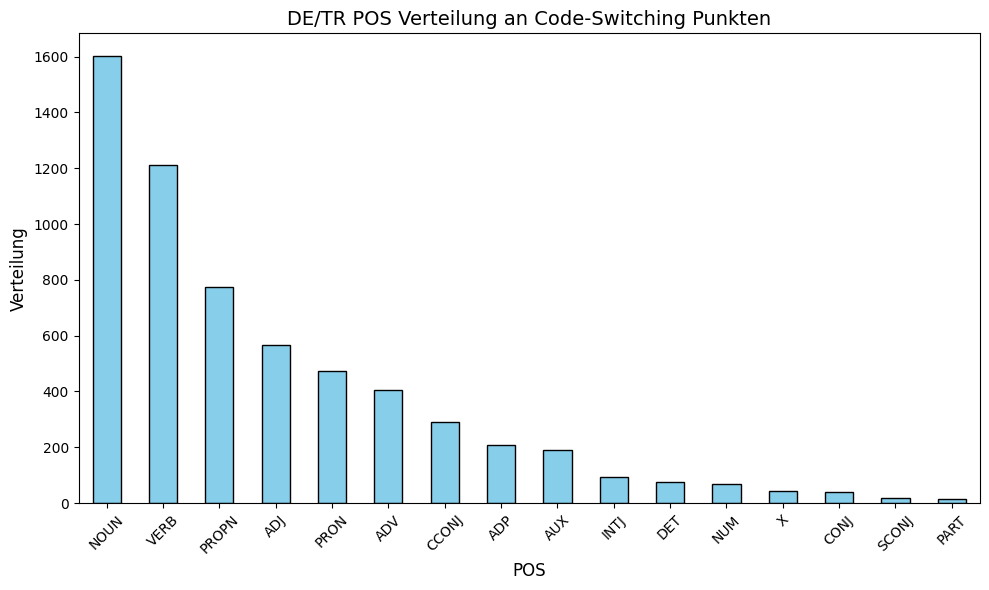

POS Verteilung im gesamten TR-DE-Korpus (außer OTHER) für DE/TR POS Verteilung im gesamten TR-DE-Korpus:
POS
NOUN     18822
VERB     17158
PRON     14373
ADV      13904
ADJ       8184
CCONJ     4747
PROPN     4353
AUX       4351
ADP       3594
DET       2735
INTJ      1801
NUM       1223
X         1135
PART      1012
SCONJ      506
CONJ       223
PUNCT       14
Name: count, dtype: int64


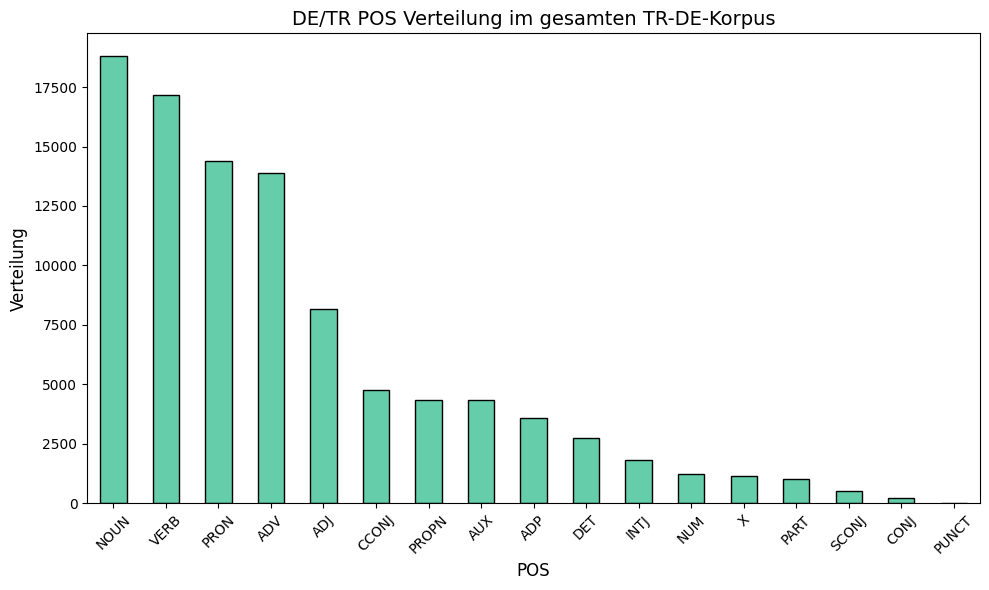


--------------------------------------------------------------------------------
WORTLÄNGEN JE POS
--------------------------------------------------------------------------------
 LANG   POS  AVG_LENGTH
   DE   ADJ    6.442544
LANG3   ADJ    5.638889
MIXED   ADJ   11.000000
   TR   ADJ    4.915946
   DE   ADP    2.805525
LANG3   ADP    2.500000
MIXED   ADP    9.000000
OTHER   ADP    1.428571
   TR   ADP    4.460648
   DE   ADV    3.812785
LANG3   ADV    3.142857
MIXED   ADV    6.000000
   TR   ADV    4.272139
   DE   AUX    3.905742
LANG3   AUX    2.500000
   TR   AUX    3.485757
   DE CCONJ    3.208292
LANG3 CCONJ    3.000000
   TR CCONJ    2.848794
   DE  CONJ    3.783333
   TR  CONJ    2.656442
   DE   DET    4.234568
LANG3   DET    2.928571
   TR   DET    1.962704
   DE  INTJ    4.527027
LANG3  INTJ    3.909091
OTHER  INTJ    4.923913
   TR  INTJ    2.853412
   DE  NOUN    6.777275
LANG3  NOUN    5.607143
MIXED  NOUN    9.255906
OTHER  NOUN    1.750000
   TR  NOUN    5.792123
   

In [ ]:
"""
Korpusüberblick TuGeBiC (TR-DE)
===============================

Markiert die Code-Switching-Punkte, gibt Kennzahlen zum Korpus aus
(Tokens, Sätze, Sprachverteilung) und erstellt die POS-Verteilungsgrafiken.
Zusätzlich: durchschnittliche Wortlänge und Silbenzahl je Sprache und POS.

Eingabe : TuGeBiC_Twitter_TRDE.csv (die Spalte CS wird bei Bedarf ergänzt)
Ausgabe : Grafik/TR_DE_POS.png, Grafik/TR_DE_POS_gesamt.png
"""

import os

import matplotlib.pyplot as plt
import pandas as pd

#from a_cs_features_tr import count_syllables


# ----------------------------------------------------------------------
# Code-Switching-Punkte
# ----------------------------------------------------------------------
def add_cs_columns(df: pd.DataFrame, force: bool = False) -> pd.DataFrame:
    """
    Erzeugt die Spalte CS.

    Ein Wort ist ein CS-Punkt (1), wenn seine Sprache von der des UNMITTELBAR
    vorangehenden Wortes im selben Satz abweicht. OTHER-Token (Satzzeichen,
    Symbole, Usernamen) sind nie CS-Punkte und unterbrechen die Vergleichskette,
    d. h. sie werden nicht übersprungen.
    """
    df_copy = df.copy()
    if force or "CS" not in df_copy.columns:
        df_copy["CS"] = [
            int(
                i > 0
                and df_copy.loc[i, "ID"] == df_copy.loc[i - 1, "ID"]
                and df_copy.loc[i, "LANG"] != df_copy.loc[i - 1, "LANG"]
                and df_copy.loc[i, "LANG"] != "OTHER"
                and df_copy.loc[i - 1, "LANG"] != "OTHER"
            )
            for i in range(len(df_copy))
        ]
    return df_copy


def report_switches_hidden_by_other(df: pd.DataFrame) -> None:
    """
    Nur Diagnose – verändert die Spalte CS nicht.
    Zählt Sprachwechsel, die nicht als CS-Punkt erfasst werden
    """
    if not {"ID", "LANG"}.issubset(df.columns):
        return

    hidden = 0
    for _, g in df.groupby("ID", sort=False):
        last_real = None        # zuletzt gesehene Sprache ungleich OTHER
        gap_since_last = False  # lag ein OTHER-Token dazwischen?
        for lang in g["LANG"]:
            if lang == "OTHER":
                if last_real is not None:
                    gap_since_last = True
                continue
            if last_real is not None and lang != last_real and gap_since_last:
                hidden += 1
            last_real = lang
            gap_since_last = False

    print(f"Sprachwechsel, die durch dazwischenliegende OTHER-Token nicht als "
          f"CS-Punkt erfasst wurden: {hidden}")
    print(" ")


# ----------------------------------------------------------------------
# Kennzahlen
# ----------------------------------------------------------------------
def compute_and_print_cs_totals(df: pd.DataFrame) -> None:
    print(f"Gesamtanzahl der Code-Switching-Punkte (CS): {int(df.get('CS', pd.Series(0)).sum())}")
    print(" ")


def compute_and_print_sentence_stats(df: pd.DataFrame) -> None:
    """Gibt Token-, Wort-, Zeichen- und Satzzahlen sowie die Sprachverteilung aus."""
    # Eine Zeile = ein Token. Die Zeichenzahl wird getrennt ausgewiesen und darf
    # nicht mit der Wortzahl verwechselt werden.
    total_tokens = len(df)
    total_characters = df["WORD"].astype(str).str.len().sum()
    total_sentences = df["ID"].nunique() if "ID" in df else 0

    # Tokens ohne OTHER – das entspricht "Wörtern" im linguistischen Sinn.
    total_words_without_other = int((df["LANG"] != "OTHER").sum()) if "LANG" in df else total_tokens

    monolingual, bilingual = 0, 0
    if {"ID", "LANG"}.issubset(df.columns):
        for _, g in df.groupby("ID"):
            langs = [l for l in g["LANG"].unique() if l != "OTHER"]
            if len(langs) <= 1:
                monolingual += 1
            else:
                bilingual += 1

    counts = df["LANG"].value_counts()
    print(f"Tokens insgesamt (inkl. OTHER): {total_tokens}")
    print(f"Wörter ohne OTHER: {total_words_without_other}")
    print(f"Zeichen insgesamt (Buchstabenanzahl, NICHT Wortanzahl): {total_characters}")
    print(f"Sätze insgesamt: {total_sentences}")
    print(f"Monolinguale Sätze: {monolingual}")
    print(f"Bilinguale Sätze: {bilingual}")
    for lang in ["DE", "TR", "ENG", "LANG3", "MIXED", "AMBIG", "OTHER"]:
        print(f"{lang}: {int(counts.get(lang, 0))}")
    print(" ")


# ----------------------------------------------------------------------
# Grafiken
# ----------------------------------------------------------------------
def _plot_pos_counts(pos_counts, output_path: str, plot_title: str, color: str) -> None:
    """Balkendiagramm einer POS-Häufigkeitsverteilung."""
    print(pos_counts)
    pos_counts.plot(kind="bar", color=color, edgecolor="black", figsize=(10, 6))
    plt.title(plot_title, fontsize=14)
    plt.xlabel("POS", fontsize=12)
    plt.ylabel("Verteilung", fontsize=12)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(output_path)
    plt.show()


def plot_pos_distribution(df: pd.DataFrame, output_path: str, plot_title: str) -> None:
    """POS-Verteilung an CS-Punkten (ohne OTHER)."""
    if not {"CS", "LANG", "POS"}.issubset(df.columns):
        print("Warnung: POS-Verteilung wird übersprungen (fehlende Spalten).")
        return
    counts = df[(df["CS"] == 1) & (df["LANG"] != "OTHER")]["POS"].value_counts()
    print(f"POS Verteilung an Code-Switching Punkten (außer OTHER) für {plot_title}:")
    _plot_pos_counts(counts, output_path, plot_title, "skyblue")


def plot_pos_distribution_full_corpus(df: pd.DataFrame, output_path: str, plot_title: str) -> None:
    """POS-Verteilung im gesamten Korpus (ohne OTHER)."""
    if not {"LANG", "POS"}.issubset(df.columns):
        print("Warnung: POS-Verteilung wird übersprungen (fehlende Spalten).")
        return
    counts = df[df["LANG"] != "OTHER"]["POS"].value_counts()
    print(f"POS Verteilung im gesamten TR-DE-Korpus (außer OTHER) für {plot_title}:")
    _plot_pos_counts(counts, output_path, plot_title, "mediumaquamarine")


# ----------------------------------------------------------------------
# Durchschnittswerte je Sprache und POS
# ----------------------------------------------------------------------
def calculate_general_length_stats(df: pd.DataFrame) -> pd.DataFrame:
    """Durchschnittliche Wortlänge (Buchstaben) je LANG und POS."""
    df_clean = df.copy()
    df_clean["WORD_LEN"] = df_clean["WORD"].astype(str).apply(len)
    stats = df_clean.groupby(["LANG", "POS"])["WORD_LEN"].mean().reset_index()
    stats.rename(columns={"WORD_LEN": "AVG_LENGTH"}, inplace=True)
    return stats.sort_values(by=["POS", "LANG"])


def calculate_general_syllable_stats(df: pd.DataFrame) -> pd.DataFrame:
    """Durchschnittliche Silbenzahl je LANG und POS (nur TR, DE, ENG)."""
    df_clean = df[df["LANG"].str.upper().isin(["TR", "DE", "ENG"])].copy()
    df_clean["SYLLABLE_COUNT"] = df_clean.apply(
        lambda row: count_syllables(str(row["WORD"]), str(row["LANG"])), axis=1
    )
    stats = df_clean.groupby(["LANG", "POS"])["SYLLABLE_COUNT"].mean().reset_index()
    stats.rename(columns={"SYLLABLE_COUNT": "AVG_SYLLABLES"}, inplace=True)
    return stats.sort_values(by=["POS", "LANG"])


# ----------------------------------------------------------------------
# Ablauf
# ----------------------------------------------------------------------
def main(input_csv: str, plot_output_path: str, plot_title: str) -> None:
    df = pd.read_csv(input_csv)
    if "CS" not in df.columns:
        print(f"Spalte CS wird zu {os.path.basename(input_csv)} hinzugefügt ...")
        df = add_cs_columns(df)
        df.to_csv(input_csv, index=False)
        print(f"{os.path.basename(input_csv)} wurde mit der Spalte CS aktualisiert.")
    else:
        print(f"{os.path.basename(input_csv)} enthält bereits die Spalte CS.")
        df = add_cs_columns(df)

    compute_and_print_cs_totals(df)
    compute_and_print_sentence_stats(df)
    report_switches_hidden_by_other(df)

    os.makedirs(os.path.dirname(plot_output_path), exist_ok=True)
    plot_pos_distribution(df, plot_output_path, plot_title)
    plot_pos_distribution_full_corpus(
        df,
        os.path.join("Grafik", "TR_DE_POS_gesamt.png"),
        "DE/TR POS Verteilung im gesamten TR-DE-Korpus",
    )

    for titel, stats in [("WORTLÄNGEN JE POS", calculate_general_length_stats(df)),
                         ("SILBENZAHLEN JE POS", calculate_general_syllable_stats(df))]:
        print("\n" + "-" * 80)
        print(titel)
        print("-" * 80)
        print(stats.to_string(index=False))
        print("-" * 80)


if __name__ == "__main__":
    input_data = "TuGeBiC_Twitter_TRDE.csv"
    plot_output = os.path.join("Grafik", "TR_DE_POS.png")
    plot_title = "DE/TR POS Verteilung an Code-Switching Punkten"

    print(f"\n{'=' * 80}")
    print(f"Verarbeite {os.path.basename(input_data)}: CS-Analyse und POS-Verteilung")
    print(f"{'-' * 80}")

    main(input_data, plot_output, plot_title)
    print("\n" + "=" * 80)

# 3) Korrelationsanalyse Silben vs. CS-Efficienz | Length vs. CS-Efficienz

*   Pearson,  Spearman, Binomial GLM
*   Eingabe: TuGeBiC_Twitter_TRDE.csv
*   Eingabe: CS_Punkte_TR22.csv

In [ ]:
"""
Auswertung und Visualisierung der TR-DE-Korpusanalyse
=====================================================

Erstellt die Grafiken und Tabellen zu den Code-Switching-Punkten:
Sprach- und POS-Verteilungen, CS-Effizienz je Wortart sowie die
Korrelationsanalyse (Pearson, Spearman, binomiales GLM) zwischen dem
Längen- bzw. Silbenverhältnis (GLR/GSR) und der CS-Effizienz.

Eingabe : TuGeBiC_Twitter_TRDE.csv, CS_Punkte_TR22.csv
Ausgabe : PNG-Dateien im Ordner Grafik/
"""

import os
import warnings

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import pearsonr, spearmanr
from statsmodels.nonparametric.smoothers_lowess import lowess as sm_lowess
#from b_cs_corpus_overview_tr import calculate_general_length_stats, calculate_general_syllable_stats

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

FILE_CS_TR = "CS_Punkte_TR22.csv"
FILE_ORIG_TR = "TuGeBiC_Twitter_TRDE.csv"
OUTPUT_DIR = "Grafik"
os.makedirs(OUTPUT_DIR, exist_ok=True)

TARGET_POS = ['ADJ', 'ADP', 'ADV', 'AUX', 'CCONJ', 'CONJ', 'DET', 'INTJ',
              'NOUN', 'NUM', 'PRON', 'PROPN', 'SCONJ', 'VERB']

COLOR_MAP = {
    "TR": "#FF4D4D", "DE": "#3498DB", "ENG": "#2ECC71", "TR/DE": "#9B59B6",
    "DE/ENG": "#1ABC9C", "MIXED": "#F39C12", "OTHER": "#95A5A6", "AMBIG": "#F1C40F",
    "LANG3": "#D7BDE2", "NOUN": "#3498DB", "VERB": "#FF6B6B", "ADJ": "#FDCB6E",
    "ADV": "#A29BFE", "PRON": "#00CEC9", "ADP": "#55E6C1", "CONJ": "#E17055",
    "CCONJ": "#E17055", "SCONJ": "#FAB1A0", "DET": "#D6A2E8", "PROPN": "#FD79A8",
    "NUM": "#74B9FF", "PART": "#FFEAA7", "INTJ": "#FF7675", "AUX": "#81ECEC",
    "PUNCT": "#B2BEC3", "X": "#636E72",
}

# Einstellungen je Metrik (Länge bzw. Silben): Farben, Spaltennamen, Beschriftungen
METRIC_STYLES = {
    "length": {
        "color_point": "#8E44AD", "color_line": "#6C3483", "color_text": "#7D3C98",
        "ratio_col": "General_Len_Ratio", "kurz_col": "KURZ_LEN",
        "avg_col": "AVG_LENGTH", "stats_func": calculate_general_length_stats,
        "title_metric": "Wortlängenverhältnis (GLR)",
        "xlabel": "Allgemeines Längenverhältnis (GLR) (max/min)\n(1,0 = identische Wortlänge; höhere Werte = größerer Unterschied)",
        "ylabel": "CS-Effizienz: Anteil der Wahl des kürzeren Worts in Prozent",
        "file_suffix": "LEN",
        # Beschriftungen der Balkendiagramme
        "bar_title": "Durchschnittliche Wortlänge",
        "bar_ylabel": "Durchschnittliche Anzahl von Buchstaben",
        "bar_xlabel": "Wortart (POS)",
        "start_text": "gesamten POS-Längen",
    },
    "syllable": {
        "color_point": "#1976D2", "color_line": "#0D47A1", "color_text": "#1565C0",
        "ratio_col": "General_Syllable_Ratio", "kurz_col": "KURZ_SILBEN",
        "avg_col": "AVG_SYLLABLES", "stats_func": calculate_general_syllable_stats,
        "title_metric": "Silbenverhältnis (GSR)",
        "xlabel": "Allgemeines Silbenverhältnis (GSR) (max/min)\n(1,0 = identische Silbenanzahl; höhere Werte = größerer Unterschied)",
        "ylabel": "CS-Effizienz: Anteil der Wahl des silbenärmeren Worts in Prozent",
        "file_suffix": "SILBEN",
        "bar_title": "Durchschnittliche Silbenlänge",
        "bar_ylabel": "Durchschnittliche Anzahl von Silben",
        "bar_xlabel": "Wortart (POS-Tags)",
        "start_text": "gesamten POS-Silbenlänge",
    },
}


# ----------------------------------------------------------------------
# Hilfsfunktionen
# ----------------------------------------------------------------------
def get_safe_color_list(series):
    """Farbliste zu den Indexwerten einer Series; Unbekanntes wird grau."""
    return [COLOR_MAP.get(str(val).strip(), "#95A5A6") for val in series.index]


def check_match(row, col_target):
    """Prüft, ob die gewählte Sprache der ökonomischeren Variante entspricht."""
    lang = str(row['LANG']).strip().upper()
    target = str(row[col_target]).strip().upper()
    options = target.split('/') if '/' in target else [target]
    return "Match" if lang in options else "Mismatch"


def add_bar_labels_pct(ax):
    """Schreibt Prozentwerte über die Balken."""
    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            ax.annotate(f'{height:.1f}%', (p.get_x() + p.get_width() / 2., height),
                        ha='center', va='bottom', fontsize=9, fontweight='bold', color='black')


def with_pos(cs_df, orig_df, only_target=True):
    """Ergänzt die POS-Spalte aus dem Originalkorpus und filtert auf TARGET_POS."""
    if 'POS' not in cs_df.columns:
        pos_map = orig_df[['ID', 'WORD', 'POS']].drop_duplicates(subset=['ID', 'WORD'])
        cs_df = cs_df.merge(pos_map, on=['ID', 'WORD'], how='left')
    df = cs_df.dropna(subset=['POS']).copy()
    return df[df['POS'].isin(TARGET_POS)] if only_target else df


def save_figure(filename):
    """Speichert die aktuelle Figure und schließt sie."""
    plt.savefig(os.path.join(OUTPUT_DIR, filename), dpi=300, bbox_inches='tight')
    plt.close()


# ----------------------------------------------------------------------
# Balkendiagramme: Durchschnittswerte je POS
# ----------------------------------------------------------------------
def plot_pos_metric(stats_df, dataset_name, metric, ax=None):
    """Durchschnittliche Wortlänge bzw. Silbenzahl je POS und Sprache."""
    style = METRIC_STYLES[metric]
    if ax is None:
        ax = plt.gca()
    data = stats_df[stats_df['POS'].isin(TARGET_POS)]
    sns.barplot(data=data, x='POS', y=style["avg_col"], hue='LANG', palette=COLOR_MAP, ax=ax)
    ax.set_title(f"{style['bar_title']} - {dataset_name}", fontweight='bold')
    ax.set_ylabel(style["bar_ylabel"])
    ax.set_xlabel(style["bar_xlabel"])
    ax.legend(title="Sprache")
    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f', padding=3, fontsize=9)


def save_general_graph(input_csv, dataset_name, output_filename, metric):
    """Berechnet die Durchschnittswerte im Gesamtkorpus und speichert die Grafik."""
    style = METRIC_STYLES[metric]
    print(f"\nStart der Analyse der {style['start_text']} für: {dataset_name}")
    stats = style["stats_func"](pd.read_csv(input_csv))

    plt.figure(figsize=(12, 6))
    plot_pos_metric(stats, dataset_name, metric, ax=plt.gca())
    plt.tight_layout()
    save_path = os.path.join(OUTPUT_DIR, output_filename)
    plt.savefig(save_path, dpi=300)
    plt.close()
    print(f"Die Grafik wurde erfolgreich gespeichert: {save_path}")


def save_cs_lengths_graphs(cs_df, orig_df, dataset_name):
    """Dieselben Balkendiagramme, aber nur für die CS-Punkte."""
    print(f"\nStart der Analyse der CS-Punkte Längen und Silben für: {dataset_name}")
    df_clean = with_pos(cs_df, orig_df)

    for metric, cols, value_col, filename in [
        ("length", ['TR_LEN', 'DE_LEN'], 'AVG_LENGTH',
         f"POS_Lengths_CS_{dataset_name.replace(' ', '_')}.png"),
        ("syllable", ['TR_SILBEN', 'DE_SILBEN'], 'AVG_SYLLABLES',
         f"POS_SilbenLengths_CS_{dataset_name.replace(' ', '_')}.png"),
    ]:
        stats = df_clean.groupby('POS')[cols].mean().reset_index()
        melted = stats.melt(id_vars='POS', var_name='LANG', value_name=value_col)
        melted['LANG'] = melted['LANG'].apply(lambda x: 'TR' if 'TR' in x else 'DE')

        plt.figure(figsize=(12, 6))
        plot_pos_metric(melted, dataset_name, metric, ax=plt.gca())
        plt.tight_layout()
        save_path = os.path.join(OUTPUT_DIR, filename)
        plt.savefig(save_path, dpi=300)
        plt.close()
        print(f"Die Grafik wurde erfolgreich gespeichert: {save_path}")


# ----------------------------------------------------------------------
# Korrelationsanalyse: Pearson, Spearman, binomiales GLM
# ----------------------------------------------------------------------
def _prepare_correlation_data(orig_df, cs_df, lang_pair, metric):
    """Datenaufbereitung: GLR bzw. GSR, CS-Effizienz und N_Efficient/N_Total je POS."""
    style = METRIC_STYLES[metric]
    lang1, lang2 = lang_pair

    if 'POS' not in cs_df.columns and not {'ID', 'WORD'}.issubset(cs_df.columns):
        return None
    cs_df = with_pos(cs_df, orig_df, only_target=False)

    stats = style["stats_func"](orig_df)
    stats = stats[stats['LANG'].isin([lang1, lang2]) & stats['POS'].isin(TARGET_POS)]
    pivot_stats = stats.pivot(index='POS', columns='LANG', values=style["avg_col"])
    if lang1 not in pivot_stats.columns or lang2 not in pivot_stats.columns:
        return None

    # Verhältnis immer als max/min, also stets >= 1
    pivot_stats[style["ratio_col"]] = (
        pivot_stats[[lang1, lang2]].max(axis=1) / pivot_stats[[lang1, lang2]].min(axis=1)
    )

    valid_cs = cs_df[cs_df[style["kurz_col"]].isin([lang1, lang2])].copy()
    if valid_cs.empty:
        return None
    valid_cs['Is_Efficient'] = (valid_cs['LANG'] == valid_cs[style["kurz_col"]]).astype(int)

    cs_counts = valid_cs.groupby('POS')['Is_Efficient'].agg(['sum', 'count']).reset_index()
    cs_counts.rename(columns={'sum': 'N_Efficient', 'count': 'N_Total'}, inplace=True)
    cs_counts['N_Inefficient'] = cs_counts['N_Total'] - cs_counts['N_Efficient']
    cs_counts['CS_Efficiency_Rate'] = (cs_counts['N_Efficient'] / cs_counts['N_Total']) * 100

    final_df = pivot_stats[[style["ratio_col"]]].merge(cs_counts, on='POS', how='inner')
    return final_df.sort_values(by=style["ratio_col"]).reset_index(drop=True)


def _label_points(final_df, ratio_col, offset, color_text, y_values=None):
    """Setzt die POS-Beschriftungen ober- bzw. unterhalb der Regressionslinie."""
    x_max = final_df[ratio_col].max()
    x_span = x_max - final_df[ratio_col].min()

    for i, row in enumerate(final_df.itertuples()):
        ref = y_values[i] if y_values is not None else None
        if ref is not None:
            va = 'bottom' if row.CS_Efficiency_Rate >= ref else 'top'
        else:
            va = 'bottom' if i % 2 == 0 else 'top'
        offset_y = offset if va == 'bottom' else -offset

        # Am rechten Rand leicht nach links rücken, damit das Label nicht überlappt
        x_val = getattr(row, ratio_col)
        ha, x_text = 'center', x_val
        if x_val >= x_max - 0.02 * x_span:
            ha, x_text = 'right', x_val - 0.015 * x_span

        plt.text(x_text, row.CS_Efficiency_Rate + offset_y, row.POS,
                 fontsize=10, fontweight='bold', color=color_text, ha=ha, va=va)


def _start_correlation_figure():
    """Einheitliches Format aller drei Korrelationsgrafiken."""
    plt.figure(figsize=(13, 11))
    sns.set_style("whitegrid", {'grid.linestyle': '--'})


def _finish_correlation_figure(style, plot_title, filename):
    """Titel und Achsenbeschriftungen setzen, Grafik speichern."""
    plt.title(plot_title, fontsize=16, fontweight='bold', pad=20)
    plt.xlabel(style["xlabel"], fontsize=12, fontweight='bold')
    plt.ylabel(style["ylabel"], fontsize=12, fontweight='bold')
    save_figure(filename)


def _print_significance(name, value, p_value):
    print(f"\n{name} = {value:.3f}, p-value = {p_value:.3f}")
    print("Die Korrelation ist statistisch signifikant." if p_value < 0.05
          else "Die Korrelation ist statistisch nicht signifikant. (p >= 0.05)")


def analyze_correlation(orig_df, cs_df, lang_pair, dataset_name, metric):
    """Pearson, Spearman und binomiales GLM für eine Metrik; speichert drei Grafiken."""
    style = METRIC_STYLES[metric]
    ratio_col = style["ratio_col"]

    print(f"\n{'=' * 60}")
    print(f"--- Korrelationsanalyse ({metric.capitalize()} vs. Efficiency): {dataset_name} ---")
    print(f"{'=' * 60}")

    final_df = _prepare_correlation_data(orig_df, cs_df, lang_pair, metric)
    if final_df is None:
        print("Warnung: Keine gültigen Daten für die Korrelationsanalyse gefunden.")
        return

    print(f"\nDaten für Korrelationsplot ({metric.capitalize()}):")
    print(final_df[['POS', ratio_col, 'CS_Efficiency_Rate', 'N_Efficient', 'N_Total']]
          .round(3).to_string(index=False))

    base_filename = f"Korrelation_{dataset_name.replace(' ', '_')}_{style['file_suffix']}"
    scatter_kws = {'s': 150, 'alpha': 0.9, 'edgecolor': 'white'}
    line_kws = {'color': style["color_line"], 'linewidth': 3}

    # 1) Pearson: lineare Regression mit 95%-Konfidenzband
    r, p_pearson = pearsonr(final_df[ratio_col], final_df['CS_Efficiency_Rate'])
    _print_significance("Pearson r", r, p_pearson)

    _start_correlation_figure()
    sns.regplot(data=final_df, x=ratio_col, y='CS_Efficiency_Rate', color=style["color_point"],
                scatter_kws=scatter_kws, line_kws=line_kws, ci=95)
    _label_points(final_df, ratio_col, offset=2.0, color_text=style["color_text"])
    _finish_correlation_figure(
        style, f"Pearson-Korrelation: {style['title_metric']} vs. CS-Effizienz",
        f"{base_filename}_Pearson.png")

    # 2) Spearman: LOWESS-Glättung statt Gerade
    rho, p_spearman = spearmanr(final_df[ratio_col], final_df['CS_Efficiency_Rate'])
    _print_significance("Spearman rho", rho, p_spearman)

    _start_correlation_figure()
    sns.regplot(data=final_df, x=ratio_col, y='CS_Efficiency_Rate', color=style["color_point"],
                scatter_kws=scatter_kws, line_kws=line_kws, lowess=True)
    lowess_fit = sm_lowess(final_df['CS_Efficiency_Rate'], final_df[ratio_col],
                           xvals=final_df[ratio_col])
    _label_points(final_df, ratio_col, offset=2.0, color_text=style["color_text"],
                  y_values=lowess_fit)
    _finish_correlation_figure(
        style, f"Spearman-Korrelation: {style['title_metric']} vs. CS-Effizienz",
        f"{base_filename}_Spearman.png")

    # 3) Binomiales GLM auf den Zählwerten (effizient vs. nicht effizient)
    glm_model = smf.glm(formula=f'N_Efficient + N_Inefficient ~ {ratio_col}',
                        data=final_df, family=sm.families.Binomial()).fit()
    print(f"\n--- Binomial GLM ({metric.capitalize()}) ---")
    print(glm_model.summary())

    x_min, x_max = final_df[ratio_col].min(), final_df[ratio_col].max()
    x_range = pd.DataFrame({ratio_col: [x_min + i * (x_max - x_min) / 99 for i in range(100)]})
    x_range['Predicted'] = glm_model.predict(x_range) * 100
    predicted_at_points = glm_model.predict(final_df[[ratio_col]]) * 100

    _start_correlation_figure()
    plt.scatter(final_df[ratio_col], final_df['CS_Efficiency_Rate'],
                s=150, alpha=0.9, color=style["color_point"], edgecolor='white', zorder=3)
    plt.plot(x_range[ratio_col], x_range['Predicted'], color=style["color_line"],
             linewidth=3, zorder=2)
    _label_points(final_df, ratio_col, offset=2.0, color_text=style["color_text"],
                  y_values=predicted_at_points.values)
    _finish_correlation_figure(
        style, f"Binomial GLM: {style['title_metric']} vs. CS-Effizienz",
        f"{base_filename}_GLM.png")

    print(f"\nGrafiken gespeichert: {base_filename}_Pearson.png / _Spearman.png / _GLM.png")


# ----------------------------------------------------------------------
# Verteilungs- und Effizienzgrafiken
# ----------------------------------------------------------------------
def _plot_pos_percentages(pos_source, title, filename):
    """POS-Verteilung in Prozent als Balkendiagramm."""
    pos_dist_pct = pos_source['POS'].value_counts(normalize=True) * 100 if not pos_source.empty else pd.Series()
    if pos_dist_pct.empty:
        print("Warnung: Keine POS-Daten gefunden.")
        return
    plt.figure(figsize=(12, 6))
    sns.barplot(x=pos_dist_pct.index, y=pos_dist_pct.values, hue=pos_dist_pct.index,
                palette=get_safe_color_list(pos_dist_pct))
    plt.xticks(rotation=90)
    plt.title(title, fontweight='bold')
    plt.ylabel("Prozent (%)")
    plt.xlabel("Wortart (POS-Tags)")
    add_bar_labels_pct(plt.gca())
    save_figure(filename)


def plot_pos_distribution_full_corpus(df_orig, dataset_name):
    """POS-Verteilung im gesamten Korpus (ohne OTHER, PUNCT und X)."""
    if 'POS' not in df_orig.columns or df_orig.empty:
        print("Warnung: POS-Verteilung (gesamtes Korpus) wird übersprungen (fehlende Daten).")
        return
    mask = (df_orig['POS'] != 'PUNCT') & (df_orig['POS'] != 'X')
    if 'LANG' in df_orig.columns:
        mask &= df_orig['LANG'] != 'OTHER'
    _plot_pos_percentages(df_orig[mask], "POS Verteilung im TR-DE-Korpus",
                          f"{dataset_name}_4b_POS_Verteilung_Gesamt.png")


def analyze_complete(cs_file, orig_file, dataset_name):
    """Sprachverteilung, Effizienz je POS und Verteilung der kürzeren Variante."""
    print(f"Starte Analyse für: {dataset_name} ")
    try:
        df_cs = pd.read_csv(cs_file)
        df_orig = pd.read_csv(orig_file) if os.path.exists(orig_file) else pd.DataFrame(columns=['POS'])
    except Exception as e:
        print(f"Fehler beim Laden der Datei: {e}")
        return

    df_cs = with_pos(df_cs, df_orig)

    # 1) Sprachverteilung an CS-Punkten
    lang_dist = df_cs['LANG'].value_counts()
    plt.figure(figsize=(10, 8))
    plt.pie(lang_dist, labels=lang_dist.index, autopct='%1.1f%%',
            colors=get_safe_color_list(lang_dist), startangle=140)
    plt.title("Sprachverteilung an CS-Punkten", fontweight='bold')
    save_figure(f"{dataset_name}_1_Sprachverteilung.png")

    # 2)/3) Effizienz je POS: Wie oft wird die kürzere bzw. silbenärmere Variante gewählt?
    for kurz_col, palette, title, filename in [
        ('KURZ_LEN', "viridis",
         "Effizienz: Wahl des kürzeren Worts (Length) nach POS an CS-Punkten",
         f"{dataset_name}_2_Effizienz_Laenge_POS.png"),
        ('KURZ_SILBEN', "magma",
         "Effizienz: Wahl des silbenärmeren Worts nach POS an CS-Punkten",
         f"{dataset_name}_3_Effizienz_Silben_POS.png"),
    ]:
        is_match = df_cs.apply(lambda x: 1 if check_match(x, kurz_col) == "Match" else 0, axis=1)
        eff_pos = df_cs.assign(_match=is_match).groupby('POS')['_match'].mean().sort_values(ascending=False) * 100

        plt.figure(figsize=(12, 6))
        sns.barplot(x=eff_pos.index, y=eff_pos.values, hue=eff_pos.index,
                    palette=palette, legend=False)
        plt.axhline(y=50, color='r', linestyle='--', alpha=0.5)
        plt.title(title, fontweight='bold')
        plt.ylabel("Anteil der Wahl (%)")
        plt.xlabel("Wortart (POS-Tags)")
        plt.ylim(0, 105)
        for i, v in enumerate(eff_pos.values):
            plt.text(i, v + 1, f"{v:.1f}%", ha='center', fontweight='bold')
        save_figure(filename)

    # 4) POS-Verteilung im CS-Punkte-Datenrahmen
    if not df_orig.empty and 'CS' in df_orig.columns:
        pos_source = df_orig[(df_orig['CS'] == 1) & (df_orig['LANG'] != 'OTHER') &
                             (df_orig['POS'] != 'PUNCT') & (df_orig['POS'] != 'X')]
    else:
        pos_source = df_orig
    _plot_pos_percentages(pos_source, "POS Verteilung im CS-Punkte-Datenrahmen",
                          f"{dataset_name}_4_POS_Verteilung.png")

    # 5)/6) Welche Sprache stellt die kürzere bzw. silbenärmere Variante?
    for kurz_col, title, filename in [
        ('KURZ_SILBEN', "Verteilung der Sprachen nach weniger Silben an Code-Switching-Punkten",
         f"{dataset_name}_5_Kurz_Silben_Verteilung.png"),
        ('KURZ_LEN', "Verteilung der Sprachen nach kürzerer Wortlänge an Code-Switching-Punkten",
         f"{dataset_name}_6_Kurz_Laenge_Verteilung.png"),
    ]:
        dist_pct = df_cs[kurz_col].value_counts(normalize=True) * 100
        plt.figure(figsize=(10, 6))
        sns.barplot(x=dist_pct.index, y=dist_pct.values, hue=dist_pct.index,
                    palette=get_safe_color_list(dist_pct))
        plt.title(title, fontweight='bold')
        plt.ylabel("Prozent (%)")
        plt.xlabel("Sprache")
        add_bar_labels_pct(plt.gca())
        save_figure(filename)


# ----------------------------------------------------------------------
# Tabellen
# ----------------------------------------------------------------------
def print_simple_efficiency_table(cs_df, orig_df):
    """CS-Effizienzrate je POS, getrennt für Länge und Silbenzahl."""
    print("\n" + "=" * 60)
    print("--- CS EFFICIENCY RATE (Syllables & Length) ---")
    print("=" * 60)

    df_clean = with_pos(cs_df, orig_df)

    tables = []
    for kurz_col, new_name in [('KURZ_LEN', 'CS_Efficiency_Rate (Length)'),
                               ('KURZ_SILBEN', 'CS_Efficiency_Rate (Syllable)')]:
        valid = df_clean[df_clean[kurz_col].isin(['TR', 'DE'])].copy()
        valid['Is_Efficient'] = (valid['LANG'].astype(str).str.strip()
                                 == valid[kurz_col].astype(str).str.strip()).astype(int)
        eff = valid.groupby('POS')['Is_Efficient'].mean().reset_index()
        tables.append(eff.rename(columns={'Is_Efficient': new_name}))

    final_eff = pd.merge(tables[0], tables[1], on='POS', how='outer')
    print(final_eff.round(3).to_string(index=False))
    print("\n")


def print_pos_averages(orig_df, lang_pair):
    """Durchschnittliche Länge und Silbenzahl je POS im Gesamtkorpus."""
    lang1, lang2 = lang_pair
    print(f"\n{'=' * 60}")
    print(f"--- Durchschnittliche Längen und Silben pro POS ({lang1} vs {lang2}) ---")
    print(f"{'=' * 60}")

    for header, stats_func, value_col, unit, ratio_name in [
        ("WORTLÄNGEN", calculate_general_length_stats, 'AVG_LENGTH', 'LEN', 'General_Length_Ratio'),
        ("SILBENLÄNGEN", calculate_general_syllable_stats, 'AVG_SYLLABLES', 'SILBEN', 'General_Syllable_Ratio'),
    ]:
        stats = stats_func(orig_df)
        stats = stats[stats['LANG'].isin([lang1, lang2]) & stats['POS'].isin(TARGET_POS)]
        pivot = stats.pivot(index='POS', columns='LANG', values=value_col).reset_index()
        col1, col2 = f'{lang1} {unit}', f'{lang2} {unit}'
        pivot.rename(columns={lang1: col1, lang2: col2}, inplace=True)
        pivot[ratio_name] = pivot[col1] / pivot[col2]

        print(f"\n------ DURCHSCHNITTLICHE {header} ------")
        print(pivot[['POS', col1, col2, ratio_name]].round(3).to_string(index=False))
    print("\n")


def print_cs_pos_averages(cs_df, orig_df):
    """Dieselben Durchschnittswerte, aber nur an den CS-Punkten."""
    print(f"\n{'=' * 60}")
    print("--- Durchschnittliche Längen und Silben pro POS (NUR CS-PUNKTE) ---")
    print(f"{'=' * 60}")

    df_clean = with_pos(cs_df, orig_df)

    for header, cols, names, ratio_name in [
        ("WORTLÄNGEN", ['TR_LEN', 'DE_LEN'], ['TR LEN', 'DE LEN'], 'CS_Length_Ratio'),
        ("SILBENLÄNGEN", ['TR_SILBEN', 'DE_SILBEN'], ['TR SILBEN', 'DE SILBEN'], 'CS_Syllable_Ratio'),
    ]:
        stats = df_clean.groupby('POS')[cols].mean().reset_index()
        stats.rename(columns=dict(zip(cols, names)), inplace=True)
        stats[ratio_name] = stats[names[0]] / stats[names[1]]

        print(f"\n------ DURCHSCHNITTLICHE {header} (CS-PUNKTE) ------")
        print(stats[['POS'] + names + [ratio_name]].round(3).to_string(index=False))
    print("\n")


# ----------------------------------------------------------------------
# Ablauf
# ----------------------------------------------------------------------
if __name__ == "__main__":
    orig_dataframe = pd.read_csv(FILE_ORIG_TR)
    cs_dataframe = pd.read_csv(FILE_CS_TR)

    # 1) Grafiken zum Gesamtkorpus
    plot_pos_distribution_full_corpus(orig_dataframe, "TR_DE_Corpus")
    analyze_complete(FILE_CS_TR, FILE_ORIG_TR, "TR_DE_Corpus")
    save_general_graph(FILE_ORIG_TR, "TR-DE Corpus", "POS_Lengths_TR.png", metric="length")
    save_general_graph(FILE_ORIG_TR, "TR-DE Corpus", "POS_SilbenLengths_TR.png", metric="syllable")

    # 2) Grafiken zu den CS-Punkten
    save_cs_lengths_graphs(cs_dataframe, orig_dataframe, "CS-Punkte-Datenrahmen")

    # 3) Tabellen
    print_pos_averages(orig_dataframe, ('TR', 'DE'))
    print_cs_pos_averages(cs_dataframe, orig_dataframe)
    print_simple_efficiency_table(cs_dataframe, orig_dataframe)

    # 4) Korrelationsanalysen (Pearson, Spearman, GLM – für Länge und Silben)
    analyze_correlation(orig_dataframe, cs_dataframe, ('TR', 'DE'), "TR-DE Corpus", metric="length")
    analyze_correlation(orig_dataframe, cs_dataframe, ('TR', 'DE'), "TR-DE Corpus", metric="syllable")

    print(f"\nFertig! Alle Ergebnisse befinden sich im Ordner '{OUTPUT_DIR}'.")

Starte Analyse für: TR_DE_Corpus 

Start der Analyse der gesamten POS-Längen für: TR-DE Corpus
Die Grafik wurde erfolgreich gespeichert: Grafik/POS_Lengths_TR.png

Start der Analyse der gesamten POS-Silbenlänge für: TR-DE Corpus
Die Grafik wurde erfolgreich gespeichert: Grafik/POS_SilbenLengths_TR.png

Start der Analyse der CS-Punkte Längen und Silben für: CS-Punkte-Datenrahmen
Die Grafik wurde erfolgreich gespeichert: Grafik/POS_Lengths_CS_CS-Punkte-Datenrahmen.png
Die Grafik wurde erfolgreich gespeichert: Grafik/POS_SilbenLengths_CS_CS-Punkte-Datenrahmen.png

--- Durchschnittliche Längen und Silben pro POS (TR vs DE) ---

------ DURCHSCHNITTLICHE WORTLÄNGEN ------
  POS  TR LEN  DE LEN  General_Length_Ratio
  ADJ   4.916   6.443                 0.763
  ADP   4.461   2.806                 1.590
  ADV   4.272   3.813                 1.120
  AUX   3.486   3.906                 0.892
CCONJ   2.849   3.208                 0.888
 CONJ   2.656   3.783                 0.702
  DET   1.963   4

# 4) BSPR DATA CLEANING

*   Eingabe: 010826_results_prod.csv (Rohausgabe von PennController)

*   Eingabe: word_cs.xlsx (CS-Markierung je Wort)

*   Ausgabe: bereinigte CSV-Dateien
---
Gespeicherte Dateien:
 - cs_point_mismatch_report.csv
 - excluded_from_lmem_log.csv
 - main_analysis_dataframe.csv
 - main_analysis_dataframe_lmem_ready.csv
 - participant_accuracy_summary.csv
 - participants_id_mapping.csv
 - questions_clean.csv
 - reading_time_events.csv
 - unparsed_or_missing_rows_report.csv

In [ ]:
"""
Aufbereitung der BSPR-Rohdaten (PCIbex)
=======================================

Eingabe : 010826_results_prod.csv (Rohausgabe von PennController)
          word_cs.xlsx            (CS-Markierung je Wort)
Ausgabe : bereinigte CSV-Dateien im Ordner Bspr_result/

Aufbau der Rohdatei (aus den Daten selbst abgeleitet)
-----------------------------------------------------
Die ersten 7 Felder haben alle Zeilen gemeinsam:
    1 SubmitTime, 2 ParticipantHash, 3 Controller, 4 ItemOrder,
    5 InnerElementNumber, 6 Label (Bedingung bzw. "intro"), 7 LatinSquareGroup

Controller == "Form"      -> 8 FieldName, 9 FieldValue
Controller == "Question"  -> 8 Frage, 9 Antwort, 10 IsCorrect (1/0/NULL),
                             11 Antwortzeit in ms
Controller == "ReversibleDashedSentence2" (Lesezeile):
    8 WordPosition (ab 1), 9 Word, 10 WordIndex (ab 0),
    11..N-1 Ereignisliste variabler Länge, letztes Feld: Newline (true/false)

Ereignisliste:
    [first_pass_RT, erste Bewegungsrichtung,
     (Tastendruck-Nr., RT, Richtung), ...]
  - first_pass_RT: Zeit auf dem Wort beim ersten Erscheinen, bis die Person
    per Vorwärts- oder Rückwärtstaste weitergeht (First-Pass-Lesezeit in ms).
  - Richtung: 1 = vorwärts, -1 = rückwärts.
  - Die weiteren Tripel beschreiben je einen erneuten Besuch; ihre Summe
    ergibt die rereading_time.

Hinweis zu negativen Werten: Lesezeiten sind nie negativ. "-1" steht immer
für eine Rückwärtsbewegung im Richtungsfeld, nie für eine Lesezeit.
"""

from pathlib import Path
from urllib.parse import unquote

import numpy as np
import pandas as pd

RAW_PATH = Path("010826_results_prod.csv")
CS_PATH = Path("word_cs.xlsx")
OUT_DIR = Path("Bspr_result")
OUT_DIR.mkdir(parents=True, exist_ok=True)

COMMON_COLS = ["submit_time", "participant_hash", "controller",
               "item_order", "inner_element_number", "label", "latin_square_group"]

# ----------------------------------------------------------------------
# 0) Rohdatei zeilenweise einlesen, Kommentarzeilen überspringen.
# ----------------------------------------------------------------------
with open(RAW_PATH, "r", encoding="utf-8") as f:
    raw_lines = [ln.rstrip("\n") for ln in f if not ln.startswith("#") and ln.strip()]

print(f"Datenzeilen ohne Kommentare: {len(raw_lines)}")

form_rows, question_rows, word_rows = [], [], []
unparsed_rows = []    # nicht lesbare oder unerwartete Zeilen
missing_rt_rows = []  # Wortzeilen ohne Lesezeitdaten

for line_no, line in enumerate(raw_lines, start=1):
    fields = line.split(",")
    if len(fields) < 8:
        unparsed_rows.append({"line_no": line_no, "raw": line, "reason": "Weniger als 8 Felder"})
        continue

    common, rest = fields[:7], fields[7:]
    controller = common[2]

    try:
        if controller == "Form":
            form_rows.append(common + [rest[0], ",".join(rest[1:])])

        elif controller == "Question":
            if len(rest) != 4:
                unparsed_rows.append({"line_no": line_no, "raw": line,
                                      "reason": f"Unerwartete Feldzahl bei Question: {len(rest)}"})
                continue
            question_rows.append(common + list(rest))

        elif controller == "ReversibleDashedSentence2":
            word_position, word_raw = rest[0], rest[1]
            event_fields = rest[2:-1]  # word_index + Ereignisliste
            newline_flag = rest[-1]

            if len(event_fields) == 0 or event_fields[0] == "":
                # Lesezeitdaten fehlen vollständig (seltener Sonderfall).
                missing_rt_rows.append({"line_no": line_no, "raw": line,
                                        "reason": "word_index/RT-Daten leer"})
                word_rows.append(common + [word_position, word_raw, np.nan, [], newline_flag,
                                           "missing_reading_time"])
                continue

            word_index = int(event_fields[0])
            nums = event_fields[1:]

            # Gültig sind: 2 Startwerte + beliebig viele vollständige Tripel.
            if len(nums) < 2 or (len(nums) - 2) % 3 != 0:
                unparsed_rows.append({"line_no": line_no, "raw": line,
                                      "reason": f"Unerwartete Länge der Ereignisliste: {len(nums)}"})
                word_rows.append(common + [word_position, word_raw, word_index, [], newline_flag,
                                           "unparsed_event_list"])
                continue

            nums = [int(n) for n in nums]
            events = [("first_pass", None, nums[0], nums[1])]
            for i in range(2, len(nums), 3):
                kp_no, rt, direction = nums[i:i + 3]
                events.append(("reread", kp_no, rt, direction))

            word_rows.append(common + [word_position, word_raw, word_index, events,
                                       newline_flag, "ok"])

        else:
            unparsed_rows.append({"line_no": line_no, "raw": line,
                                  "reason": f"Unbekannter Controller: {controller}"})
    except Exception as e:
        unparsed_rows.append({"line_no": line_no, "raw": line, "reason": f"Exception: {e}"})

print(f"Form-Zeilen: {len(form_rows)} | Question-Zeilen: {len(question_rows)} | "
      f"Wortzeilen: {len(word_rows)}")
print(f"Nicht lesbare Zeilen: {len(unparsed_rows)} | Zeilen ohne RT: {len(missing_rt_rows)}")

# ----------------------------------------------------------------------
# 1) Form-Daten: Zuordnung Hash <-> ParticipantID.
# ----------------------------------------------------------------------
df_form = pd.DataFrame(form_rows, columns=COMMON_COLS + ["field_name", "field_value"])
df_participants = (
    df_form[df_form["field_name"] == "ParticipantID"]
    [["participant_hash", "field_value"]]
    .rename(columns={"field_value": "participant_id"})
    .drop_duplicates()
    .reset_index(drop=True)
)
print(f"\nAnzahl der Versuchspersonen: {df_participants.shape[0]}")

id_map = dict(zip(df_participants["participant_hash"], df_participants["participant_id"]))

# ----------------------------------------------------------------------
# 2) Verständnisfragen.
# ----------------------------------------------------------------------
df_q = pd.DataFrame(question_rows, columns=COMMON_COLS +
                    ["question_text_raw", "given_answer_raw", "is_correct_raw", "answer_time_ms_raw"])

df_q["participant_id"] = df_q["participant_hash"].map(id_map)
df_q["item_order"] = df_q["item_order"].astype(int)
df_q = df_q.rename(columns={"label": "experimental_condition"})
df_q["question_text"] = df_q["question_text_raw"].apply(unquote)
df_q["given_answer"] = df_q["given_answer_raw"].apply(unquote)
df_q["is_correct"] = df_q["is_correct_raw"].replace({"NULL": np.nan}).astype(float)
df_q["answer_time_ms"] = pd.to_numeric(df_q["answer_time_ms_raw"], errors="coerce")

df_questions = df_q[[
    "participant_id", "participant_hash", "item_order", "experimental_condition",
    "latin_square_group", "question_text", "given_answer", "is_correct", "answer_time_ms",
    "submit_time"
]].sort_values(["participant_id", "item_order"]).reset_index(drop=True)

# ----------------------------------------------------------------------
# 3) Trefferquote je Versuchsperson.
# ----------------------------------------------------------------------
acc = (
    df_questions.groupby("participant_id")
    .agg(total_questions=("is_correct", "size"),
         correct_answers=("is_correct", lambda s: int(s.sum(skipna=True))))
    .reset_index()
)
acc["incorrect_answers"] = acc["total_questions"] - acc["correct_answers"]
acc["accuracy"] = acc["correct_answers"] / acc["total_questions"]
acc["error_rate"] = acc["incorrect_answers"] / acc["total_questions"]
# Fehlerquote über 1/3 gilt als ungeeignet.
acc["suitability"] = np.where(acc["error_rate"] > (1 / 3), "not suitable", "suitable")

df_participant_accuracy = acc.merge(df_participants, on="participant_id", how="left")[
    ["participant_id", "participant_hash", "total_questions", "correct_answers",
     "incorrect_answers", "accuracy", "error_rate", "suitability"]
].sort_values("participant_id").reset_index(drop=True)

print("\nTrefferquote je Versuchsperson:")
print(df_participant_accuracy.to_string(index=False))

# ----------------------------------------------------------------------
# 4) Lesezeiten: Ereignis- und Wortebene.
# ----------------------------------------------------------------------
word_cols = COMMON_COLS + ["word_position", "word_raw", "word_index_0based",
                           "events", "newline_flag", "parse_status"]
df_words_raw = pd.DataFrame(word_rows, columns=word_cols)

df_words_raw["participant_id"] = df_words_raw["participant_hash"].map(id_map)
df_words_raw["item_order"] = df_words_raw["item_order"].astype(int)
df_words_raw = df_words_raw.rename(columns={"label": "experimental_condition"})
df_words_raw["word_position"] = df_words_raw["word_position"].astype(int)
df_words_raw["word"] = df_words_raw["word_raw"].apply(unquote)
df_words_raw["newline_flag"] = df_words_raw["newline_flag"].map({"true": True, "false": False})

# --- Ereignisebene: eine Zeile je Besuch. ---
event_records = []
for _, row in df_words_raw.iterrows():
    for visit_no, (event_type, kp_no, rt, direction) in enumerate(row["events"], start=1):
        event_records.append({
            "participant_id": row["participant_id"],
            "participant_hash": row["participant_hash"],
            "item_order": row["item_order"],
            "experimental_condition": row["experimental_condition"],
            "latin_square_group": row["latin_square_group"],
            "word_position": row["word_position"],
            "word": row["word"],
            "visit_number": visit_no,
            "event_type": event_type,              # first_pass / reread
            "keypress_number_trial_local": kp_no,  # bei first_pass NaN
            "reading_time_ms": rt,
            "move_direction": "forward" if direction == 1 else "backward",
        })

df_reading_events = pd.DataFrame(event_records).sort_values(
    ["participant_id", "item_order", "word_position", "visit_number"]
).reset_index(drop=True)


# --- Wortebene: die eigentliche Analyseeinheit. ---
def summarize_events(events):
    """Fasst die Besuche eines Wortes zu First-Pass-, Rereading- und Gesamtzeit zusammen."""
    if not events:
        return pd.Series({
            "first_pass_reading_time": np.nan,
            "first_pass_move_direction": np.nan,
            "num_reread_events": 0,
            "rereading_time": 0.0,
            "total_reading_time": np.nan,
            "had_regression": False,
        })
    first, rereads = events[0], events[1:]
    first_pass_rt = first[2]
    reread_rt_sum = sum(ev[2] for ev in rereads)
    return pd.Series({
        "first_pass_reading_time": first_pass_rt,
        "first_pass_move_direction": "forward" if first[3] == 1 else "backward",
        "num_reread_events": len(rereads),
        "rereading_time": reread_rt_sum,
        "total_reading_time": first_pass_rt + reread_rt_sum,
        "had_regression": len(rereads) > 0,
    })


summary = df_words_raw["events"].apply(summarize_events)
df_word_level = pd.concat([df_words_raw.drop(columns=["events"]), summary], axis=1)

# ----------------------------------------------------------------------
# 4b) CS-Punkte aus word_cs.xlsx zuordnen.
# ----------------------------------------------------------------------
# word_cs.xlsx enthält die Wörter jedes Satzes in Reihenfolge und ohne
# Satzzeichen. Die 52 Sätze stehen in derselben Reihenfolge und haben dieselbe
# Wortzahl wie die 52 item_order-Werte im Hauptdatensatz.
df_cs = pd.read_excel(CS_PATH)

sentence_order = df_cs["Sentence"].drop_duplicates().tolist()
item_order_sorted = sorted(df_word_level["item_order"].unique())

if len(sentence_order) != len(item_order_sorted):
    raise ValueError(
        f"Die Satzzahl in word_cs.xlsx ({len(sentence_order)}) stimmt nicht mit der "
        f"Itemzahl im Hauptdatensatz ({len(item_order_sorted)}) überein!"
    )

# item_order -> {Wortposition (ab 1): CS-Wert}
cs_lookup = {}
cs_mismatch_report = []
n_participants = df_word_level["participant_id"].nunique()
for item_id, sentence in zip(item_order_sorted, sentence_order):
    cs_values = df_cs.loc[df_cs["Sentence"] == sentence, "CS"].tolist()
    n_main = (df_word_level["item_order"] == item_id).sum() // n_participants
    if len(cs_values) != n_main:
        cs_mismatch_report.append({
            "item_order": item_id, "sentence": sentence,
            "n_words_main": int(n_main), "n_words_cs_file": len(cs_values),
        })
    cs_lookup[item_id] = {pos + 1: cs for pos, cs in enumerate(cs_values)}

df_cs_mismatch_report = pd.DataFrame(cs_mismatch_report)
if not df_cs_mismatch_report.empty:
    print("\nWARNUNG: Für folgende Items stimmt die Wortzahl nicht mit word_cs.xlsx "
          "überein; cs_point wird dort auf NaN gesetzt:")
    print(df_cs_mismatch_report.to_string(index=False))

df_word_level["cs_point"] = df_word_level.apply(
    lambda row: cs_lookup.get(row["item_order"], {}).get(row["word_position"], np.nan), axis=1
)
n_missing_cs = df_word_level["cs_point"].isna().sum()
if n_missing_cs:
    print(f"\nWARNUNG: Für {n_missing_cs} Wortzeilen konnte cs_point nicht zugeordnet werden (NaN).")

# ----------------------------------------------------------------------
# 5) Hauptdatensatz: Versuchsperson x Item x Wort.
# ----------------------------------------------------------------------
df_analysis = df_word_level.merge(
    df_participant_accuracy[["participant_id", "total_questions", "correct_answers",
                             "incorrect_answers", "accuracy", "error_rate", "suitability"]],
    on="participant_id", how="left"
)

df_analysis = df_analysis[[
    "participant_id", "participant_hash",
    "item_order", "latin_square_group", "experimental_condition",
    "word_position", "word_index_0based", "word", "word_raw", "cs_point",
    "first_pass_reading_time", "first_pass_move_direction",
    "num_reread_events", "rereading_time", "total_reading_time", "had_regression",
    "newline_flag", "parse_status",
    "suitability", "error_rate", "accuracy",
]].sort_values(["participant_id", "item_order", "word_position"]).reset_index(drop=True)

# ----------------------------------------------------------------------
# 6) Bericht über fehlende oder nicht lesbare Datensätze.
# ----------------------------------------------------------------------
df_unparsed_report = pd.DataFrame(unparsed_rows + missing_rt_rows)
if df_unparsed_report.empty:
    df_unparsed_report = pd.DataFrame(columns=["line_no", "raw", "reason"])

# ----------------------------------------------------------------------
# 7) Dateien speichern.
# ----------------------------------------------------------------------
df_participant_accuracy.to_csv(OUT_DIR / "participant_accuracy_summary.csv", index=False)
df_questions.to_csv(OUT_DIR / "questions_clean.csv", index=False)
df_reading_events.to_csv(OUT_DIR / "reading_time_events.csv", index=False)
df_analysis.to_csv(OUT_DIR / "main_analysis_dataframe.csv", index=False)
df_unparsed_report.to_csv(OUT_DIR / "unparsed_or_missing_rows_report.csv", index=False)
df_participants.to_csv(OUT_DIR / "participants_id_mapping.csv", index=False)
df_cs_mismatch_report.to_csv(OUT_DIR / "cs_point_mismatch_report.csv", index=False)

# ----------------------------------------------------------------------
# 8) Datei für die LMEM-Analyse (Complete Cases).
# ----------------------------------------------------------------------
# Zeilen ohne aufgezeichnete Lesezeit (parse_status != "ok") werden listenweise
# ausgeschlossen, nicht imputiert: Mittelwert- oder Medianimputation würde die
# Varianzschätzung der Zufallseffekte und die p-Werte verzerren. Die
# ausgeschlossenen Zeilen werden zur Kontrolle protokolliert.
excluded_mask = df_analysis["parse_status"] != "ok"
df_excluded_for_lmem = df_analysis.loc[excluded_mask].copy()
df_analysis_lmem_ready = df_analysis.loc[~excluded_mask].reset_index(drop=True)

df_excluded_for_lmem.to_csv(OUT_DIR / "excluded_from_lmem_log.csv", index=False)
df_analysis_lmem_ready.to_csv(OUT_DIR / "main_analysis_dataframe_lmem_ready.csv", index=False)

print(f"\nDaten für die LMEM-Analyse: {df_analysis_lmem_ready.shape[0]} Zeilen "
      f"({excluded_mask.sum()} Zeilen wegen fehlender Lesezeiten ausgeschlossen "
      f"-> excluded_from_lmem_log.csv).")

print("\nGespeicherte Dateien:")
for p in sorted(OUT_DIR.glob("*.csv")):
    print(" -", p.name)

print("\ndf_analysis:", df_analysis.shape)
print("df_reading_events:", df_reading_events.shape)
print("df_questions:", df_questions.shape)

Datenzeilen ohne Kommentare: 16992
Form-Zeilen: 18 | Question-Zeilen: 936 | Wortzeilen: 16038
Nicht lesbare Zeilen: 0 | Zeilen ohne RT: 2

Anzahl der Versuchspersonen: 18

Trefferquote je Versuchsperson:
participant_id                 participant_hash  total_questions  correct_answers  incorrect_answers  accuracy  error_rate suitability
      Bemule16 be555773996213fb9bd87c773ae933c2               52               49                  3  0.942308    0.057692    suitable
      GUSIIS17 07b8c430bdbd43331d7d84d642a881c1               52               51                  1  0.980769    0.019231    suitable
      GÜZAZO02 704b8fcb14422193988e7cb658940b2e               52               41                 11  0.788462    0.211538    suitable
      MEMEER16 0a9be44c512145657104365695f488bf               52               44                  8  0.846154    0.153846    suitable
      NAAHBR10 be60987ceabd428b4f4c3af4fed2ba35               52               45                  7  0.865385    0.13461

# 5) Surprisal computation with XGLM-1.7B (Creates: Surprisal_values.csv)

*   Eingabe:  word_cs.xlsx (Spalten: Type, Sentence-Type, Sentence, Word, CS)

*   Ausgabe : surprisal_values.csv


          


In [ ]:
"""
Surprisal-Werte auf Wortebene mit XGLM-1.7B
===========================================

Eingabe : word_cs.xlsx (Spalten: Type, Sentence-Type, Sentence, Word, CS)
          Sentence = vollständiger Satz mit Satzzeichen,
          Word     = Wörter in Reihenfolge, ohne Satzzeichen.
Ausgabe : Bspr_result/surprisal_values.csv

Methode
-------
Wörter werden über inkrementelle Tokenisierung den Subword-Token zugeordnet:
Der Satz wird Wort für Wort verlängert und jedes Mal neu tokenisiert; die neu
hinzugekommenen Token-IDs gehören zum jeweiligen Wort. Das ist robuster als
die Auswertung der SentencePiece-Whitespace-Marker.

Das Wort-Surprisal ist die Summe von -log P(Token | vorheriger Kontext) über
alle Subword-Token des Wortes (Teacher Forcing, ein Forward-Pass pro Satz).

Hinweis: Der Checkpoint facebook/xglm-1.7B ist rund 7 GB groß und benötigt
Internetzugang sowie ausreichend RAM/VRAM. Eine GPU wird automatisch genutzt.
"""

import math
from pathlib import Path

import pandas as pd
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

# ----------------------------------------------------------------------
# 0) Einstellungen
# ----------------------------------------------------------------------
CS_PATH = Path("word_cs.xlsx")
OUT_DIR = Path("Bspr_result")
OUT_DIR.mkdir(parents=True, exist_ok=True)

MODEL_NAME = "facebook/xglm-1.7B"
OUT_FILE = "surprisal_values.csv"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE = torch.float16 if DEVICE == "cuda" else torch.float32

# Beginnt bei 2, damit item_order zu main_analysis_dataframe_lmem_ready.csv
# passt: dort laufen die Werte lückenlos von 2 bis 53 und entsprechen der
# Reihenfolge des ersten Auftretens der Sätze in word_cs.xlsx.
FIRST_ITEM_ORDER = 2

LN2 = math.log(2)

# ----------------------------------------------------------------------
# 1) Modell und Tokenizer laden
# ----------------------------------------------------------------------
print(f"Lade Modell: {MODEL_NAME} (device={DEVICE}) ...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(MODEL_NAME, torch_dtype=DTYPE)
model.to(DEVICE)
model.eval()


# ----------------------------------------------------------------------
# 2) Zuordnung Wort -> Subword-Token
# ----------------------------------------------------------------------
def align_words_to_tokens(words, tokenizer):
    """
    Ordnet jedem Wort seine Token-IDs zu.

    Rückgabe: die Token-IDs des ganzen Satzes sowie je Wort die halboffene
    Tokenspanne (start, end) – end ist ausgeschlossen.
    """
    prev_ids = tokenizer.encode("", add_special_tokens=True)
    word_token_spans = []
    running_text = ""

    for w in words:
        running_text = w if running_text == "" else running_text + " " + w
        ids = tokenizer.encode(running_text, add_special_tokens=True)

        # Nicht jeder Tokenizer ist präfixstabil; die Länge des gemeinsamen
        # Präfixes ist daher die sicherste Zuordnung.
        common_len = 0
        max_common = min(len(prev_ids), len(ids))
        while common_len < max_common and prev_ids[common_len] == ids[common_len]:
            common_len += 1

        start, end = common_len, len(ids)
        if end <= start:
            # Seltener Fall: Das Wort erzeugt kein neues Token. Es wird
            # trotzdem mindestens ein Token zugewiesen, damit die Spanne gilt.
            start = max(start - 1, len(prev_ids))
            end = max(end, start + 1)

        word_token_spans.append((start, end))
        prev_ids = ids

    return prev_ids, word_token_spans


@torch.no_grad()
def compute_sentence_surprisal(sentence_words, tokenizer, model, device):
    """Berechnet das Surprisal (in nats) je Wort eines Satzes."""
    full_ids, spans = align_words_to_tokens(sentence_words, tokenizer)
    input_ids = torch.tensor([full_ids], device=device)
    logits = model(input_ids).logits[0]                # (seq_len, vocab)
    log_probs = torch.log_softmax(logits.float(), dim=-1)

    # Surprisal von Token t: -log P(token_t | token_<t), also über logits[t-1].
    token_surprisal_nats = torch.full((len(full_ids),), float("nan"))
    for t in range(1, len(full_ids)):
        token_surprisal_nats[t] = -log_probs[t - 1, full_ids[t]]

    word_surprisal_nats, n_tokens_per_word = [], []
    for start, end in spans:
        vals = token_surprisal_nats[start:end]
        vals = vals[~torch.isnan(vals)]
        word_surprisal_nats.append(float(vals.sum()) if len(vals) else float("nan"))
        n_tokens_per_word.append(end - start)

    return word_surprisal_nats, n_tokens_per_word


# ----------------------------------------------------------------------
# 3) word_cs.xlsx satzweise verarbeiten
# ----------------------------------------------------------------------
df_cs = pd.read_excel(CS_PATH)
sentence_order = df_cs["Sentence"].drop_duplicates().tolist()

all_rows = []
for i, sentence in enumerate(sentence_order):
    item_order = FIRST_ITEM_ORDER + i
    grp = df_cs.loc[df_cs["Sentence"] == sentence].reset_index(drop=True)
    words_with_punct = sentence.split()  # Wörter inkl. Satzzeichen

    if len(words_with_punct) != len(grp):
        print(f"WARNUNG: Wortzahl stimmt nicht für item_order={item_order} "
              f"({len(words_with_punct)} vs. {len(grp)}); Satz wird übersprungen.")
        continue

    word_surprisal_nats, n_tokens = compute_sentence_surprisal(
        words_with_punct, tokenizer, model, DEVICE
    )

    for pos in range(len(grp)):
        nats = word_surprisal_nats[pos]
        all_rows.append({
            "item_order": item_order,
            "word_position": pos + 1,
            "word": grp["Word"][pos],
            "word_with_punct": words_with_punct[pos],
            "cs_point": int(grp["CS"][pos]),
            "type": grp["Type"][pos],
            "sentence_type": grp["Sentence-Type"][pos],
            "sentence": sentence,
            "surprisal_nats": nats,
            "surprisal_bits": nats / LN2 if nats == nats else float("nan"),  # nats == nats: NaN-Test
            "n_subword_tokens": n_tokens[pos],
        })
    print(f"item_order={item_order} fertig ({len(grp)} Wörter).")

df_surprisal = pd.DataFrame(all_rows)

# ----------------------------------------------------------------------
# 4) Speichern – Spaltenlayout passend für das LMEM-Skript
# ----------------------------------------------------------------------
df_surprisal["surprisal"] = df_surprisal["surprisal_bits"]  # Standardeinheit: bits
df_surprisal.to_csv(OUT_DIR / OUT_FILE, index=False)

print(f"\nGespeichert: {OUT_DIR / OUT_FILE}  ({len(df_surprisal)} Zeilen)")
print(df_surprisal.head(14)[["item_order", "word_position", "word", "cs_point",
                             "surprisal_bits", "n_subword_tokens"]].to_string(index=False))

print(df_surprisal.groupby("cs_point")["surprisal_bits"]
      .agg(["count", "mean", "std", "min", "max"]).to_string())

Lade Modell: facebook/xglm-1.7B (device=cuda) ...


config.json:   0%|          | 0.00/548 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/335 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.03M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/276 [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/388 [00:00<?, ?it/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 3.47GB            

model.safetensors: downloading bytes:           |  0.00B            

generation_config.json:   0%|          | 0.00/168 [00:00<?, ?B/s]

item_order=2 fertig (14 Wörter).
item_order=3 fertig (9 Wörter).
item_order=4 fertig (18 Wörter).
item_order=5 fertig (19 Wörter).
item_order=6 fertig (18 Wörter).
item_order=7 fertig (46 Wörter).
item_order=8 fertig (13 Wörter).
item_order=9 fertig (5 Wörter).
item_order=10 fertig (12 Wörter).
item_order=11 fertig (20 Wörter).
item_order=12 fertig (50 Wörter).
item_order=13 fertig (24 Wörter).
item_order=14 fertig (22 Wörter).
item_order=15 fertig (10 Wörter).
item_order=16 fertig (11 Wörter).
item_order=17 fertig (15 Wörter).
item_order=18 fertig (60 Wörter).
item_order=19 fertig (20 Wörter).
item_order=20 fertig (23 Wörter).
item_order=21 fertig (23 Wörter).
item_order=22 fertig (47 Wörter).
item_order=23 fertig (25 Wörter).
item_order=24 fertig (39 Wörter).
item_order=25 fertig (26 Wörter).
item_order=26 fertig (10 Wörter).
item_order=27 fertig (17 Wörter).
item_order=28 fertig (6 Wörter).
item_order=29 fertig (14 Wörter).
item_order=30 fertig (14 Wörter).
item_order=31 fertig (9 W

# 5.1) Surprisal computation with XGLM-564M (Creates: small_surprisal_values.csv)

*   Eingabe:  word_cs.xlsx (Spalten: Type, Sentence-Type, Sentence, Word, CS)

*   Ausgabe : small_surprisal_values.csv


In [ ]:
"""
Surprisal-Werte auf Wortebene mit XGLM-564M
===========================================

Methodisch identisch zu e_XGLM_surprisal_values.py; nur Checkpoint und
Ausgabedatei unterscheiden sich. Genau darin liegt der Zweck: XGLM-564M und
XGLM-1.7B teilen Architektur, Tokenizer und Trainingsdaten, sodass Unterschiede
in der Vorhersage der Lesezeiten allein auf die Modellkapazität zurückgehen
(vgl. Oh & Schuler 2023).

Eingabe : word_cs.xlsx (Spalten: Type, Sentence-Type, Sentence, Word, CS)
Ausgabe : Bspr_result/small_surprisal_values.csv

Methode
-------
Wörter werden über inkrementelle Tokenisierung den Subword-Token zugeordnet:
Der Satz wird Wort für Wort verlängert und jedes Mal neu tokenisiert; die neu
hinzugekommenen Token-IDs gehören zum jeweiligen Wort.

Das Wort-Surprisal ist die Summe von -log P(Token | vorheriger Kontext) über
alle Subword-Token des Wortes (Teacher Forcing, ein Forward-Pass pro Satz).

Hinweis: Der Checkpoint ist mit rund 2,5 GB deutlich kleiner als das
1,7B-Modell und läuft daher auch auf der CPU in vertretbarer Zeit.
"""

import math
from pathlib import Path

import pandas as pd
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

# ----------------------------------------------------------------------
# 0) Einstellungen
# ----------------------------------------------------------------------
CS_PATH = Path("word_cs.xlsx")
OUT_DIR = Path("Bspr_result")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Nur diese beiden Zeilen unterscheiden sich von e_XGLM_surprisal_values.py.
MODEL_NAME = "facebook/xglm-564M"
OUT_FILE = "small_surprisal_values.csv"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE = torch.float16 if DEVICE == "cuda" else torch.float32

# Beginnt bei 2, damit item_order zu main_analysis_dataframe_lmem_ready.csv
# passt (dort lückenlos von 2 bis 53, in der Satzreihenfolge aus word_cs.xlsx).
FIRST_ITEM_ORDER = 2

LN2 = math.log(2)

# ----------------------------------------------------------------------
# 1) Modell und Tokenizer laden
# ----------------------------------------------------------------------
print(f"Lade Modell: {MODEL_NAME} (device={DEVICE}) ...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(MODEL_NAME, torch_dtype=DTYPE)
model.to(DEVICE)
model.eval()


# ----------------------------------------------------------------------
# 2) Zuordnung Wort -> Subword-Token
# ----------------------------------------------------------------------
def align_words_to_tokens(words, tokenizer):
    """
    Ordnet jedem Wort seine Token-IDs zu.

    Rückgabe: die Token-IDs des ganzen Satzes sowie je Wort die halboffene
    Tokenspanne (start, end) – end ist ausgeschlossen.
    """
    prev_ids = tokenizer.encode("", add_special_tokens=True)
    word_token_spans = []
    running_text = ""

    for w in words:
        running_text = w if running_text == "" else running_text + " " + w
        ids = tokenizer.encode(running_text, add_special_tokens=True)

        # Nicht jeder Tokenizer ist präfixstabil; die Länge des gemeinsamen
        # Präfixes ist daher die sicherste Zuordnung.
        common_len = 0
        max_common = min(len(prev_ids), len(ids))
        while common_len < max_common and prev_ids[common_len] == ids[common_len]:
            common_len += 1

        start, end = common_len, len(ids)
        if end <= start:
            # Seltener Fall: Das Wort erzeugt kein neues Token. Es wird
            # trotzdem mindestens ein Token zugewiesen, damit die Spanne gilt.
            start = max(start - 1, len(prev_ids))
            end = max(end, start + 1)

        word_token_spans.append((start, end))
        prev_ids = ids

    return prev_ids, word_token_spans


@torch.no_grad()
def compute_sentence_surprisal(sentence_words, tokenizer, model, device):
    """Berechnet das Surprisal (in nats) je Wort eines Satzes."""
    full_ids, spans = align_words_to_tokens(sentence_words, tokenizer)
    input_ids = torch.tensor([full_ids], device=device)
    logits = model(input_ids).logits[0]                # (seq_len, vocab)
    log_probs = torch.log_softmax(logits.float(), dim=-1)

    # Surprisal von Token t: -log P(token_t | token_<t), also über logits[t-1].
    token_surprisal_nats = torch.full((len(full_ids),), float("nan"))
    for t in range(1, len(full_ids)):
        token_surprisal_nats[t] = -log_probs[t - 1, full_ids[t]]

    word_surprisal_nats, n_tokens_per_word = [], []
    for start, end in spans:
        vals = token_surprisal_nats[start:end]
        vals = vals[~torch.isnan(vals)]
        word_surprisal_nats.append(float(vals.sum()) if len(vals) else float("nan"))
        n_tokens_per_word.append(end - start)

    return word_surprisal_nats, n_tokens_per_word


# ----------------------------------------------------------------------
# 3) word_cs.xlsx satzweise verarbeiten
# ----------------------------------------------------------------------
df_cs = pd.read_excel(CS_PATH)
sentence_order = df_cs["Sentence"].drop_duplicates().tolist()

all_rows = []
for i, sentence in enumerate(sentence_order):
    item_order = FIRST_ITEM_ORDER + i
    grp = df_cs.loc[df_cs["Sentence"] == sentence].reset_index(drop=True)
    words_with_punct = sentence.split()  # Wörter inkl. Satzzeichen

    if len(words_with_punct) != len(grp):
        print(f"WARNUNG: Wortzahl stimmt nicht für item_order={item_order} "
              f"({len(words_with_punct)} vs. {len(grp)}); Satz wird übersprungen.")
        continue

    word_surprisal_nats, n_tokens = compute_sentence_surprisal(
        words_with_punct, tokenizer, model, DEVICE
    )

    for pos in range(len(grp)):
        nats = word_surprisal_nats[pos]
        all_rows.append({
            "item_order": item_order,
            "word_position": pos + 1,
            "word": grp["Word"][pos],
            "word_with_punct": words_with_punct[pos],
            "cs_point": int(grp["CS"][pos]),
            "type": grp["Type"][pos],
            "sentence_type": grp["Sentence-Type"][pos],
            "sentence": sentence,
            "surprisal_nats": nats,
            "surprisal_bits": nats / LN2 if nats == nats else float("nan"),  # nats == nats: NaN-Test
            "n_subword_tokens": n_tokens[pos],
        })
    print(f"item_order={item_order} fertig ({len(grp)} Wörter).")

df_surprisal = pd.DataFrame(all_rows)

# ----------------------------------------------------------------------
# 4) Speichern – gleiches Spaltenlayout wie surprisal_values.csv, damit
#    dasselbe LMEM-Skript beide Dateien lesen kann.
# ----------------------------------------------------------------------
df_surprisal["surprisal"] = df_surprisal["surprisal_bits"]  # Standardeinheit: bits
df_surprisal.to_csv(OUT_DIR / OUT_FILE, index=False)
print(f"\nGespeichert: {OUT_DIR / OUT_FILE}  ({len(df_surprisal)} Zeilen)")

# Deskriptive Statistik
print("\nMittleres Surprisal (bits) nach CS-Status:")
print(df_surprisal.groupby("cs_point")["surprisal_bits"]
      .agg(["count", "mean", "std", "min", "max"]).to_string())

print("\nErste Zeilen:")
print(df_surprisal.head(14)[["item_order", "word_position", "word", "cs_point",
                             "surprisal_bits", "n_subword_tokens"]].to_string(index=False))

Lade Modell: facebook/xglm-564M (device=cuda) ...


config.json:   0%|          | 0.00/546 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/433 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.03M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/276 [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/388 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/168 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.13GB            

model.safetensors: downloading bytes:           |  0.00B            

item_order=2 fertig (14 Wörter).
item_order=3 fertig (9 Wörter).
item_order=4 fertig (18 Wörter).
item_order=5 fertig (19 Wörter).
item_order=6 fertig (18 Wörter).
item_order=7 fertig (46 Wörter).
item_order=8 fertig (13 Wörter).
item_order=9 fertig (5 Wörter).
item_order=10 fertig (12 Wörter).
item_order=11 fertig (20 Wörter).
item_order=12 fertig (50 Wörter).
item_order=13 fertig (24 Wörter).
item_order=14 fertig (22 Wörter).
item_order=15 fertig (10 Wörter).
item_order=16 fertig (11 Wörter).
item_order=17 fertig (15 Wörter).
item_order=18 fertig (60 Wörter).
item_order=19 fertig (20 Wörter).
item_order=20 fertig (23 Wörter).
item_order=21 fertig (23 Wörter).
item_order=22 fertig (47 Wörter).
item_order=23 fertig (25 Wörter).
item_order=24 fertig (39 Wörter).
item_order=25 fertig (26 Wörter).
item_order=26 fertig (10 Wörter).
item_order=27 fertig (17 Wörter).
item_order=28 fertig (6 Wörter).
item_order=29 fertig (14 Wörter).
item_order=30 fertig (14 Wörter).
item_order=31 fertig (9 W

# 6) RT und Surprisal (XGLM-564M) Vergleich mit LMEM

1.   Listeneintrag
2.   Listeneintrag



*  Eingabe: main_analysis_dataframe_lmem_ready.csv
*  Eingabe: small_surprisal_values.csv
*  Ausgabe: Bspr_result/ (gefilterte Daten, feste Effekte, Zusammenfassung, Grafik)
---
Gespeicherte Dateien:
 - main_analysis_with_surprisal_filtered.csv
 - fixed_effects_breakdown.csv

In [ ]:
"""
LMEM: Zusammenhang zwischen LLM-Surprisal und menschlicher Lesezeit
===================================================================

Geschätzt wird ein Modell:

    log_reading_time ~ surprisal_z * cs_point
                       + (1 + surprisal_z | participant_id) + (1 | item_order)

Da cs_point mit 0/1 kodiert ist, gibt die Zeile "surprisal_z" die
Surprisal-Steigung an Nicht-Wechselpunkten wieder, "cs_point" den
zusätzlichen Aufwand am Sprachwechsel bei mittlerer Surprisal und
"surprisal_z:cs_point" die Differenz beider Steigungen.

Eingabe : main_analysis_dataframe_lmem_ready.csv, small_surprisal_values.csv (XGLM-564M)
Ausgabe : Bspr_result/ (gefilterte Daten, feste Effekte)

Benötigt pymer4 >= 0.9 (conda-Installation, siehe colab_setup_every_session.py).
"""

from pathlib import Path

import numpy as np
import pandas as pd
import polars as pl
from pymer4.models import lmer

# ----------------------------------------------------------------------
# Einstellungen
# ----------------------------------------------------------------------
#READING_TIME_FILE = Path("main_analysis_dataframe_lmem_ready.csv")
READING_TIME_FILE = Path("/content/Bspr_result/main_analysis_dataframe_lmem_ready.csv")
SURPRISAL_FILE = Path("/content/Bspr_result/small_surprisal_values.csv")
OUTPUT_DIR = Path("Bspr_result")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# REML=True ist lme4-Voreinstellung und für die Berichterstattung der festen
# Effekte üblich.
USE_REML = True

RANDOM_EFFECTS = "+ (1 + surprisal_z | participant_id) + (1 | item_order)"

# ----------------------------------------------------------------------
# Daten laden, zusammenführen und filtern
# ----------------------------------------------------------------------
reading_times = pd.read_csv(READING_TIME_FILE)
surprisal = pd.read_csv(SURPRISAL_FILE)[["item_order", "word_position", "surprisal"]]

data = reading_times.merge(surprisal, on=["item_order", "word_position"], how="left")
data = data.dropna(subset=["surprisal", "first_pass_reading_time"]).reset_index(drop=True)
print(f"Zeilen im Modell (vor Filtern): {len(data)}")

# Erstes Wort je Satz ausschließen: Es war beim BSPR sofort sichtbar (kein
# Tastendruck nötig), die First-Pass-Zeit misst dort also keine reguläre
# Worterkennung, sondern u. a. die Pause vor Satzbeginn.
n_before = len(data)
data = data[data["word_position"] != 1].reset_index(drop=True)
print(f"Erstes Wort je Satz entfernt: {n_before - len(data)} Zeilen ({len(data)} verbleiben)")

# Ausreißerfilter nach Oh & Schuler (2023) und Chen et al. (2026):
# First-Pass-Lesezeiten unter 100 ms oder über 3000 ms werden entfernt.
n_before = len(data)
data = data[(data["first_pass_reading_time"] >= 100)
            & (data["first_pass_reading_time"] <= 3000)].reset_index(drop=True)
print(f"Durch RT-Filter (100–3000 ms) entfernt: {n_before - len(data)} Zeilen "
      f"({len(data)} verbleiben)")

data["surprisal_z"] = (data["surprisal"] - data["surprisal"].mean()) / data["surprisal"].std()
data["log_reading_time"] = np.log(data["first_pass_reading_time"])
data["cs_point"] = data["cs_point"].astype(int)
data["participant_id"] = data["participant_id"].astype(str)
data["item_order"] = data["item_order"].astype(str)

# Rohwert des Surprisal unter eigenem Namen sichern: i_surprisal_rt_sample.py
# und j_surprisal_rt_all_sample.py greifen auf "surprisal_raw" zu.
data["surprisal_raw"] = data["surprisal"]

# Wortzahlen aus den Daten berechnen (nach dem Entfernen des ersten Wortes
# stimmen fest eingetragene Werte nicht mehr).
word_index = data[["item_order", "word_position", "cs_point"]].drop_duplicates()
n_words_all = len(word_index)
n_words_cs = int(word_index["cs_point"].sum())
n_words_non_cs = n_words_all - n_words_cs
print(f"\nWörter im Modell: {n_words_all} gesamt | {n_words_non_cs} Nicht-CS | {n_words_cs} CS")

data_pl = pl.from_pandas(data)  # pymer4 >= 0.9 erwartet polars


# ----------------------------------------------------------------------
# Modell schätzen
# ----------------------------------------------------------------------
def fit_model(formula, data_pl, use_reml=USE_REML):
    """Schätzt ein Modell; ältere pymer4-Versionen kennen REML in fit() nicht."""
    m = lmer(formula, data=data_pl)
    try:
        m.fit(REML=use_reml)
    except TypeError:
        if not use_reml:
            print("Hinweis: Diese pymer4-Version akzeptiert REML nicht in fit(); "
                  "es wird die Voreinstellung (REML=True) verwendet.")
        m.fit()
    return m


def as_pandas(result):
    return result.to_pandas() if hasattr(result, "to_pandas") else pd.DataFrame(result)


model = fit_model(f"log_reading_time ~ surprisal_z * cs_point {RANDOM_EFFECTS}", data_pl)
effects = as_pandas(model.result_fit)

print("\n--- Modell: surprisal_z * cs_point ---")
print(effects.to_string(index=False))


# ----------------------------------------------------------------------
# Effekte auf der Millisekunden-Skala (Rücktransformation aus log)
# ----------------------------------------------------------------------
def get_estimate(term):
    return float(effects.loc[effects["term"] == term, "estimate"].iloc[0])


intercept = get_estimate("(Intercept)")
b_surprisal = get_estimate("surprisal_z")
b_cs = get_estimate("cs_point")
b_interaction = get_estimate("surprisal_z:cs_point")

baseline_ms = np.exp(intercept)
slope_cs = b_surprisal + b_interaction

print("\n--- Interpretationshilfe (Rücktransformation) ---")
print(f"Vorhergesagte Lesezeit an Nicht-Wechselpunkten bei mittlerer Surprisal: "
      f"{baseline_ms:.0f} ms")
print(f"Surprisal-Steigung an Nicht-Wechselpunkten: {b_surprisal:+.4f} log-Einheiten "
      f"= {100 * (np.exp(b_surprisal) - 1):+.1f} % pro SD")
print(f"Surprisal-Steigung an Wechselpunkten (Summe aus Haupteffekt und Interaktion): "
      f"{slope_cs:+.4f} log-Einheiten = {100 * (np.exp(slope_cs) - 1):+.1f} % pro SD")
print(f"Haupteffekt Sprachwechsel: {b_cs:+.4f} log-Einheiten "
      f"= {100 * (np.exp(b_cs) - 1):+.1f} % bzw. "
      f"{baseline_ms * (np.exp(b_cs) - 1):+.0f} ms")


# ----------------------------------------------------------------------
# Surprisal-Steigung an Wechselpunkten als Kontrast
# ----------------------------------------------------------------------
# Die Steigung an Wechselpunkten ist die Summe zweier geschätzter Koeffizienten
# und erscheint deshalb nicht als eigene Zeile in der Ergebnistabelle. Ihr
# Standardfehler folgt aus der Varianz-Kovarianz-Matrix der festen Effekte:
#     SE = sqrt(Var(b1) + Var(b3) + 2 * Cov(b1, b3))
# Das entspricht emmeans::emtrends und erfordert kein zweites Modell.
def fixed_effects_vcov(model):
    """Holt die Varianz-Kovarianz-Matrix der festen Effekte aus dem Modell."""
    for attr in ("vcov", "vcov_", "coef_vcov", "fixef_vcov"):
        value = getattr(model, attr, None)
        if value is not None:
            return np.asarray(value)

    # Rückfallebene über das zugrunde liegende R-Objekt.
    for attr in ("model_obj", "r_model", "_model"):
        r_model = getattr(model, attr, None)
        if r_model is not None:
            from rpy2.robjects import r as _r
            return np.asarray(_r["as.matrix"](_r["vcov"](r_model)))

    raise AttributeError("Varianz-Kovarianz-Matrix in dieser pymer4-Version nicht "
                         "zugänglich; Kontrast kann nicht berechnet werden.")


try:
    from scipy import stats

    V = fixed_effects_vcov(model)
    terms = list(effects["term"])
    i = terms.index("surprisal_z")
    j = terms.index("surprisal_z:cs_point")

    se_cs = float(np.sqrt(V[i, i] + V[j, j] + 2 * V[i, j]))
    t_cs = slope_cs / se_cs
    # Konservative Näherung: kleinere der beiden Satterthwaite-df.
    df_cs = float(min(effects.loc[i, "df"], effects.loc[j, "df"]))
    p_cs = float(2 * stats.t.sf(abs(t_cs), df_cs))
    ci_low, ci_high = (slope_cs - stats.t.ppf(0.975, df_cs) * se_cs,
                       slope_cs + stats.t.ppf(0.975, df_cs) * se_cs)

    print("\n--- Kontrast: Surprisal-Steigung an Wechselpunkten ---")
    print(f"beta = {slope_cs:.4f}, SE = {se_cs:.4f}, "
          f"95%-KI [{ci_low:.4f}; {ci_high:.4f}], "
          f"t({df_cs:.1f}) = {t_cs:.2f}, p = {p_cs:.4f}")
    print("(Freiheitsgrade konservativ genähert; der Wert beruht auf demselben "
          "Modell und nicht auf einer erneuten Schätzung.)")

    pd.DataFrame([{
        "term": "surprisal_z at cs_point = 1", "estimate": slope_cs, "std_error": se_cs,
        "conf_low": ci_low, "conf_high": ci_high, "t_stat": t_cs, "df": df_cs,
        "p_value": p_cs,
    }]).to_csv(OUTPUT_DIR / "contrast_cs_slope.csv", index=False)

except Exception as exc:
    print(f"\nHinweis: Kontrast konnte nicht berechnet werden ({exc}).")

# ----------------------------------------------------------------------
# Ergebnisse speichern
# ----------------------------------------------------------------------
data.to_csv(OUTPUT_DIR / "main_analysis_with_surprisal_filtered.csv", index=False)
effects.to_csv(OUTPUT_DIR / "fixed_effects_breakdown.csv", index=False)

print(f"\nGespeichert in {OUTPUT_DIR}/")

Zeilen im Modell (vor Filtern): 16036
Erstes Wort je Satz entfernt: 936 Zeilen (15100 verbleiben)
Durch RT-Filter (100–3000 ms) entfernt: 79 Zeilen (15021 verbleiben)

Wörter im Modell: 839 gesamt | 746 Nicht-CS | 93 CS
R messages: 
Derivatives (gradient and/or Hessian) not available. Cannot assess
  convergence through gradient-based checks.

Convergence status
: [1] FALSE
attr(,"gradient")
[1] NA


--- Modell: surprisal_z * cs_point ---
                term  estimate  std_error  conf_low  conf_high    t_stat           df      p_value
         (Intercept)  6.039876   0.072310  5.887859   6.191892 83.527299    17.838768 1.377632e-24
         surprisal_z  0.022701   0.007720  0.006691   0.038710  2.940467    22.027130 7.560992e-03
            cs_point  0.074906   0.013551  0.048345   0.101468  5.527748 14953.638795 3.297948e-08
surprisal_z:cs_point -0.004715   0.008428 -0.021236   0.011805 -0.559442 14953.723751 5.758682e-01

--- Interpretationshilfe (Rücktransformation) ---
Vorhergesag

In [ ]:
import pandas as pd, numpy as np
from scipy.stats import skew

d = pd.read_csv("Bspr_result/main_analysis_with_surprisal_filtered.csv")
print(skew(d["first_pass_reading_time"]), skew(d["log_reading_time"]))

2.9711825843292425 0.6400760575181242


# 7) RT und Surprisal (XGLM-1.7B und XGLM-564M) || Vergleich zwischen dem kleinen und dem großen Modell mit LMEM

*  Eingabe: main_analysis_dataframe_lmem_ready.csv
*  Eingabe: surprisal_values.csv (XGLM-1.7B)
*  Eingabe: small_surprisal_values.csv (XGLM-564M)
*  Ausgabe: Bspr_result/modellvergleich_summary.csv

In [ ]:
"""
Modellvergleich: XGLM-564M vs. XGLM-1.7B
========================================

Dieselbe LMEM-Analyse wie in g_Lmem_Surprisal.py, nacheinander für zwei
Surprisal-Quellen. Geschätzt wird jeweils nur das Interaktionsmodell

    log_reading_time ~ surprisal_z * cs_point
                       + (1 + surprisal_z | participant_id) + (1 | item_order)

sowie ein Basismodell ohne Surprisal als Referenz für den
Log-Likelihood-Vergleich.

Beide Sprachmodelle teilen Architektur, Tokenizer und Trainingsdaten und
unterscheiden sich nur in der Kapazität. Nach Oh & Schuler (2023) ist zu
erwarten, dass das kleinere Modell die Lesezeiten besser vorhersagt.

Eingabe : main_analysis_dataframe_lmem_ready.csv
          surprisal_values.csv        (XGLM-1.7B)
          small_surprisal_values.csv  (XGLM-564M)
Ausgabe : Bspr_result/modellvergleich_summary.csv

Beide Analysen laufen auf identisch gefilterten Zeilen, damit der Vergleich
fair ist; das Skript prüft das und bricht bei Abweichung ab.
"""

from pathlib import Path

import numpy as np
import pandas as pd
import polars as pl
from pymer4.models import lmer

# ----------------------------------------------------------------------
# Einstellungen
# ----------------------------------------------------------------------
READING_TIME_FILE = Path("main_analysis_dataframe_lmem_ready.csv")
#READING_TIME_FILE = Path("/content/Bspr_result/main_analysis_dataframe_lmem_ready.csv")
OUTPUT_DIR = Path("Bspr_result")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SURPRISAL_SOURCES = {
    "XGLM-564M": Path("small_surprisal_values.csv"),
    "XGLM-1.7B": Path("surprisal_values.csv"),
}

RT_LOWER, RT_UPPER = 100, 3000

# Der Log-Likelihood-Vergleich zwischen Basismodell (ohne Surprisal) und
# Interaktionsmodell erfordert ML statt REML, da sich die festen Effekte
# unterscheiden.
USE_REML = False

RANDOM_EFFECTS = "+ (1 + surprisal_z | participant_id) + (1 | item_order)"


# ----------------------------------------------------------------------
# Datenaufbereitung (identisch zu g_Lmem_Surprisal.py)
# ----------------------------------------------------------------------
def prepare_data(reading_time_file, surprisal_file, verbose=True):
    reading_times = pd.read_csv(reading_time_file)
    surprisal = pd.read_csv(surprisal_file)[["item_order", "word_position", "surprisal"]]

    data = reading_times.merge(surprisal, on=["item_order", "word_position"], how="left")
    data = data.dropna(subset=["surprisal", "first_pass_reading_time"]).reset_index(drop=True)

    # Erstes Wort jedes Satzes ausschließen (beim BSPR sofort sichtbar).
    n_before = len(data)
    data = data[data["word_position"] != 1].reset_index(drop=True)
    n_first_word = n_before - len(data)

    # Ausreißerfilter nach Oh & Schuler (2023) und Chen et al. (2026).
    n_before = len(data)
    data = data[(data["first_pass_reading_time"] >= RT_LOWER)
                & (data["first_pass_reading_time"] <= RT_UPPER)].reset_index(drop=True)
    n_rt = n_before - len(data)

    if verbose:
        print(f"  Erstes Wort entfernt: {n_first_word} | "
              f"RT-Filter entfernt: {n_rt} | verbleiben: {len(data)}")

    data["surprisal_z"] = (data["surprisal"] - data["surprisal"].mean()) / data["surprisal"].std()
    data["log_reading_time"] = np.log(data["first_pass_reading_time"])
    data["cs_point"] = data["cs_point"].astype(int)
    data["participant_id"] = data["participant_id"].astype(str)
    data["item_order"] = data["item_order"].astype(str)
    return data


def as_pandas(result):
    return result.to_pandas() if hasattr(result, "to_pandas") else pd.DataFrame(result)


def get_row(effects_table, term):
    return effects_table[effects_table["term"] == term].iloc[0]


def fit_model(formula, data_pl, use_reml=USE_REML):
    """Schätzt ein Modell; ältere pymer4-Versionen kennen REML in fit() nicht."""
    m = lmer(formula, data=data_pl)
    try:
        m.fit(REML=use_reml)
    except TypeError:
        if not use_reml:
            print("  Hinweis: Diese pymer4-Version akzeptiert REML nicht in fit(); "
                  "der Log-Likelihood-Vergleich beruht daher auf REML-Werten und ist "
                  "nur eingeschränkt interpretierbar.")
        m.fit()
    return m


def try_loglik(model):
    """Liest die Log-Likelihood aus; der Attributname variiert je pymer4-Version."""
    for attr in ("logLike", "log_likelihood", "loglike"):
        val = getattr(model, attr, None)
        if isinstance(val, (int, float)):
            return float(val)

    stats = getattr(model, "result_fit_stats", None)
    if stats is not None:
        try:
            stats_df = as_pandas(stats)
            for col in stats_df.columns:
                if "log" in col.lower() and "lik" in col.lower():
                    return float(stats_df[col].iloc[0])
        except Exception:
            pass
    return np.nan


# ----------------------------------------------------------------------
# Analyse je Surprisal-Quelle
# ----------------------------------------------------------------------
def run_analysis(label, surprisal_file):
    print(f"\n{'=' * 70}\n{label}  ({surprisal_file.name})\n{'=' * 70}")
    data = prepare_data(READING_TIME_FILE, surprisal_file)
    data_pl = pl.from_pandas(data)

    model = fit_model(f"log_reading_time ~ surprisal_z * cs_point {RANDOM_EFFECTS}", data_pl)
    # Basismodell ohne Surprisal: Referenz für den Log-Likelihood-Vergleich.
    baseline = fit_model("log_reading_time ~ 1 + (1 | participant_id) + (1 | item_order)",
                         data_pl)

    effects = as_pandas(model.result_fit)

    print("\n--- Modell: surprisal_z * cs_point ---")
    print(effects.to_string(index=False))

    ll_model = try_loglik(model)
    ll_baseline = try_loglik(baseline)
    delta_ll = (ll_model - ll_baseline
                if not (np.isnan(ll_model) or np.isnan(ll_baseline)) else np.nan)

    rows = []
    for group, term in [
        ("Surprisal (Non-CS slope)", "surprisal_z"),
        ("CS main effect", "cs_point"),
        ("Interaction (surprisal x CS)", "surprisal_z:cs_point"),
    ]:
        r = get_row(effects, term)
        rows.append({
            "model": label, "group": group, "n_obs": len(data),
            "estimate": r["estimate"], "se": r["std_error"],
            "ci_low": r["conf_low"], "ci_high": r["conf_high"],
            "t_stat": r["t_stat"], "p_value": r["p_value"],
            "delta_loglik": delta_ll,
        })

    return pd.DataFrame(rows), len(data)


all_results, n_obs_seen = [], {}
for label, path in SURPRISAL_SOURCES.items():
    res, n_obs = run_analysis(label, path)
    all_results.append(res)
    n_obs_seen[label] = n_obs

if len(set(n_obs_seen.values())) != 1:
    raise ValueError("Die beiden Analysen laufen auf unterschiedlich vielen Zeilen "
                     f"({n_obs_seen}). Ein Vergleich wäre dadurch verzerrt.")

summary = pd.concat(all_results, ignore_index=True)
summary.to_csv(OUTPUT_DIR / "modellvergleich_summary.csv", index=False)

print(f"\n{'=' * 70}\nVERGLEICH\n{'=' * 70}")
print(summary.to_string(index=False))

if summary["delta_loglik"].notna().any():
    print("\nDelta Log-Likelihood gegenüber dem Basismodell ohne Surprisal "
          "(höher = bessere Vorhersage der Lesezeiten):")
    print(summary.groupby("model")["delta_loglik"].first().to_string())
else:
    print("\nHinweis: Log-Likelihood konnte aus dieser pymer4-Version nicht ausgelesen "
          "werden. Der Vergleich stützt sich dann auf Steigungen und t-Werte.")

print(f"\nGespeichert in {OUTPUT_DIR}/")


XGLM-564M  (small_surprisal_values.csv)
  Erstes Wort entfernt: 936 | RT-Filter entfernt: 79 | verbleiben: 15021
R messages: 
Derivatives (gradient and/or Hessian) not available. Cannot assess
  convergence through gradient-based checks.

Convergence status
: [1] FALSE
attr(,"gradient")
[1] NA

R messages: 
Derivatives (gradient and/or Hessian) not available. Cannot assess
  convergence through gradient-based checks.

Convergence status
: [1] FALSE
attr(,"gradient")
[1] NA


--- Modell: surprisal_z * cs_point ---
                term  estimate  std_error  conf_low  conf_high    t_stat           df      p_value
         (Intercept)  6.039876   0.072310  5.887859   6.191892 83.527299    17.838768 1.377632e-24
         surprisal_z  0.022701   0.007720  0.006691   0.038710  2.940467    22.027130 7.560992e-03
            cs_point  0.074906   0.013551  0.048345   0.101468  5.527748 14953.638795 3.297948e-08
surprisal_z:cs_point -0.004715   0.008428 -0.021236   0.011805 -0.559442 14953.72375

# 8) Sentence-level plot: LLM surprisal vs. human reading time (1 Example)

*  Eingabe: main_analysis_with_surprisal_filtered.csv
*  Ausgabe: sentence_item<N>_word_table.csv
*  Ausgabe: sentence_item<N>_surprisal_vs_rt.png

Stimulussatz (item_order=2): Hose und Schuhe hab ich, bir Oberteil eksik, onu da ablamdan yürütürüm, napim.

 word_position       word  cs_point  surprisal    mean_rt  median_rt  n_participants
             2       Hose         1  23.738003 486.722222      313.5              18
             3        und         0  13.138104 499.722222      363.0              18
             4     Schuhe         0  23.008327 463.111111      370.0              18
             5        hab         0  15.590614 445.444444      383.0              18
             6       ich,         0  25.441594 377.833333      342.0              18
             7        bir         1  34.039373 578.388889      322.5              18
             8   Oberteil         1  48.282707 423.352941      366.0              17
             9     eksik,         1  42.996051 562.647059      490.0              17
            10        onu         0  13.297201 485.111111      403.0              18
            11         da         0  15.6

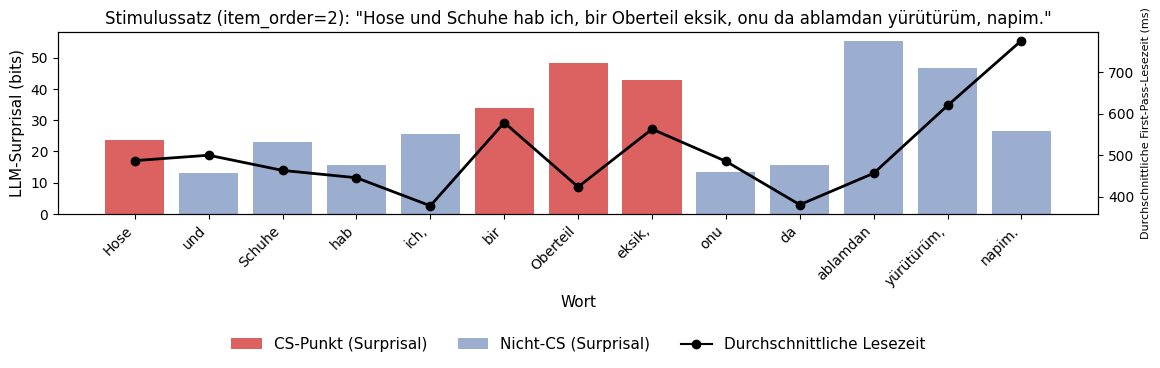


Gespeichert: Bspr_result/sentence_item2_surprisal_vs_rt.png


In [2]:
"""
Einzelsatz-Grafik: LLM-Surprisal vs. menschliche Lesezeit
=========================================================

Zeigt für einen Satz (item_order) je Wort das LLM-Surprisal als Balken und die
mittlere First-Pass-Lesezeit der Versuchspersonen als Linie auf zweiter Achse;
CS-Punkte sind farblich hervorgehoben.

Eingabe : Bspr_result/main_analysis_with_surprisal_filtered.csv
          (Versuchsperson x Item x Wort, mit surprisal_raw,
          first_pass_reading_time und cs_point)
Ausgabe : Bspr_result/sentence_item<N>_word_table.csv
          Bspr_result/sentence_item<N>_surprisal_vs_rt.png
"""

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

IN_PATH = Path("Bspr_result/main_analysis_with_surprisal_filtered.csv")
OUT_DIR = Path("Bspr_result")
OUT_DIR.mkdir(parents=True, exist_ok=True)

ITEM_ORDER = 2  # <-- hier den gewünschten Satz eintragen

df = pd.read_csv(IN_PATH)
sub = df[df["item_order"] == ITEM_ORDER].copy()

# Wortebene: Surprisal ist für alle Versuchspersonen gleich (erster Wert),
# die Lesezeit wird über die Versuchspersonen gemittelt.
word_summary = (
    sub.groupby(["word_position", "word", "cs_point"], sort=True)
    .agg(surprisal=("surprisal_raw", "first"),
         mean_rt=("first_pass_reading_time", "mean"),
         median_rt=("first_pass_reading_time", "median"),
         n_participants=("first_pass_reading_time", "size"))
    .reset_index()
    .sort_values("word_position")
)

sentence_text = " ".join(word_summary["word"])
print(f"Stimulussatz (item_order={ITEM_ORDER}): {sentence_text}\n")
print(word_summary.to_string(index=False))
word_summary.to_csv(OUT_DIR / f"sentence_item{ITEM_ORDER}_word_table.csv", index=False)

# ----------------------------------------------------------------------
# Grafik: zwei Achsen (Surprisal = Balken, Lesezeit = Linie)
# ----------------------------------------------------------------------
fig, ax1 = plt.subplots(figsize=(max(8, len(word_summary) * 0.9), 5))

x = np.arange(len(word_summary))
colors = ["#d64545" if cs == 1 else "#8aa0c8" for cs in word_summary["cs_point"]]

ax1.bar(x, word_summary["surprisal"], color=colors, alpha=0.85)
ax1.set_ylabel("LLM-Surprisal (bits)", fontsize=11)
ax1.set_xticks(x)
ax1.set_xticklabels(word_summary["word"], rotation=45, ha="right")
ax1.set_xlabel("Wort", fontsize=11)

ax2 = ax1.twinx()
ax2.plot(x, word_summary["mean_rt"], color="black", marker="o", linewidth=2)
ax2.set_ylabel("Durchschnittliche First-Pass-Lesezeit (ms)", fontsize=8)

# Legende unterhalb der Achsen, damit sie die Lesezeitlinie nicht überdeckt.
legend_elems = [
    Patch(facecolor="#d64545", alpha=0.85, label="CS-Punkt (Surprisal)"),
    Patch(facecolor="#8aa0c8", alpha=0.85, label="Nicht-CS (Surprisal)"),
    Line2D([0], [0], color="black", marker="o", label="Durchschnittliche Lesezeit"),
]
ax1.legend(handles=legend_elems, loc="upper center", bbox_to_anchor=(0.5, -0.60),
           ncol=3, fontsize=11, frameon=False)

plt.title(f"Stimulussatz (item_order={ITEM_ORDER}): \"{sentence_text}\"", fontsize=12)
plt.tight_layout()

out_path = OUT_DIR / f"sentence_item{ITEM_ORDER}_surprisal_vs_rt.png"
plt.savefig(out_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"\nGespeichert: {out_path}")

# 8.1) Small-multiples grid: monolingual and multilingual sentences, separately

*  Eingabe: main_analysis_with_surprisal_filtered.csv
*  Eingabe: word_cs.xlsx
*  Ausgabe: monolingual_sentences_grid.png
*  Ausgabe: multilingual_sentences_grid.png

Gespeichert: Bspr_result/monolingual_sentences_grid.pdf  (26 Sätze)


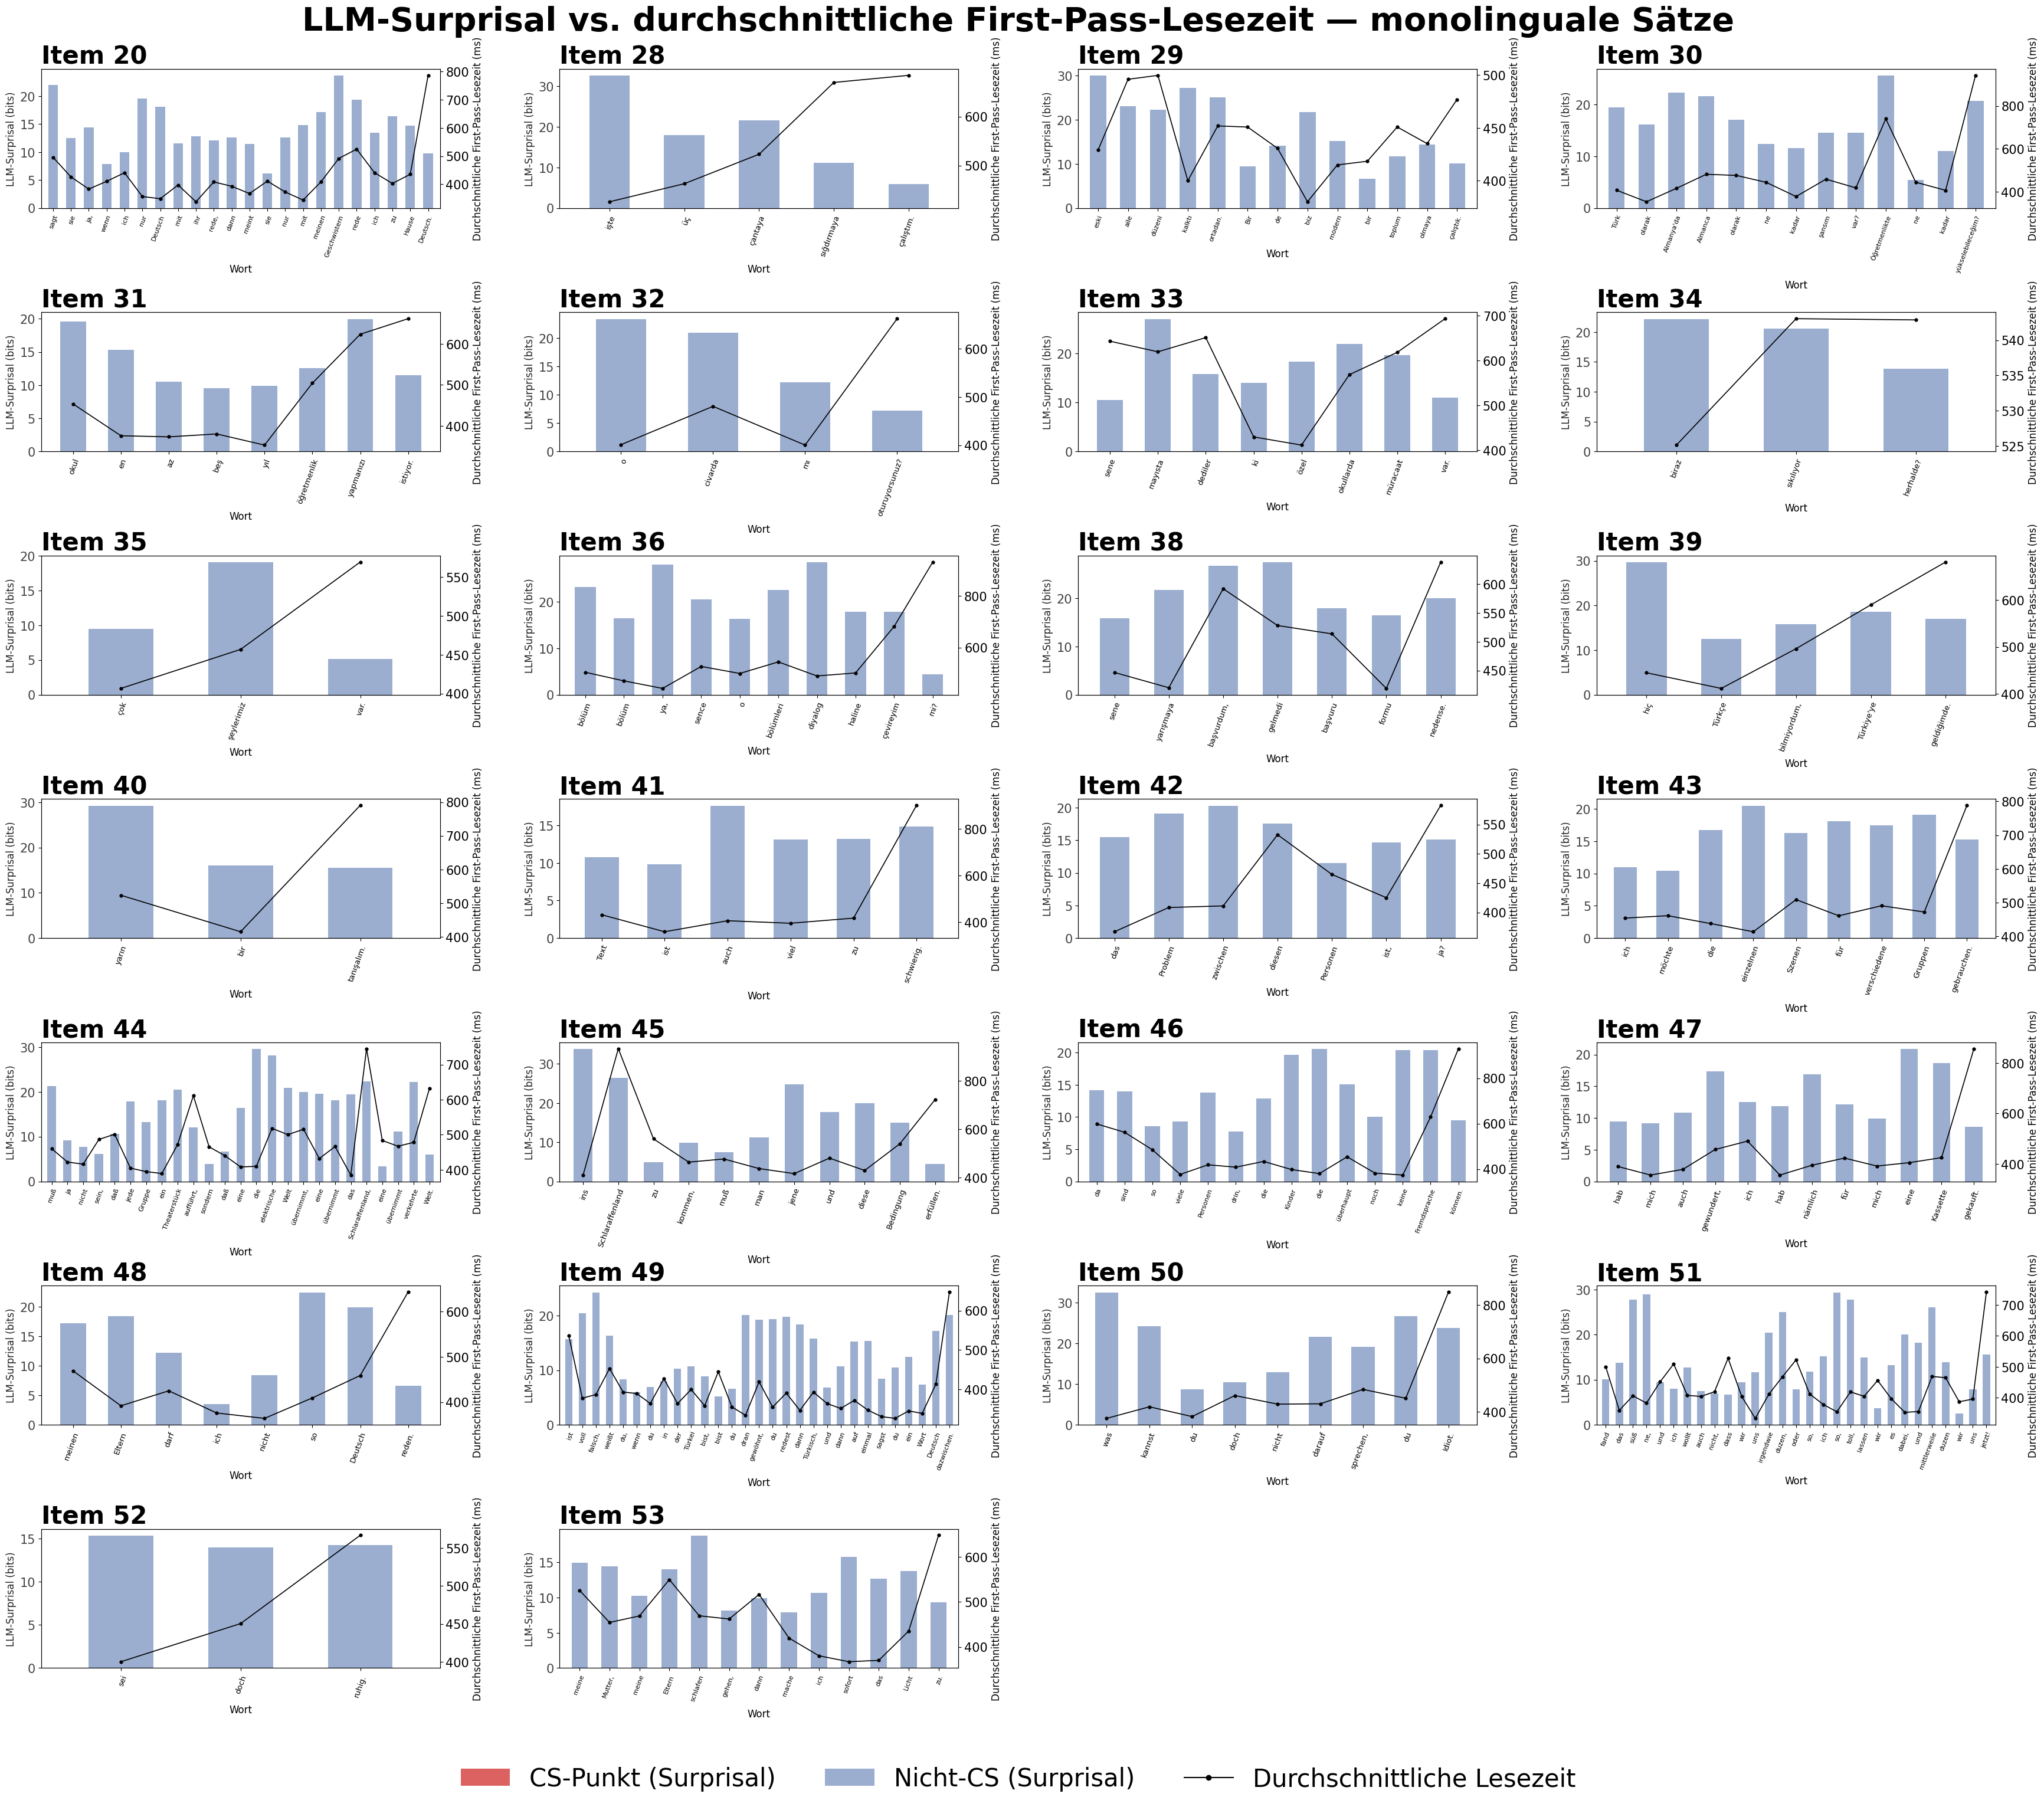

Gespeichert: Bspr_result/multilingual_sentences_grid.pdf  (26 Sätze)


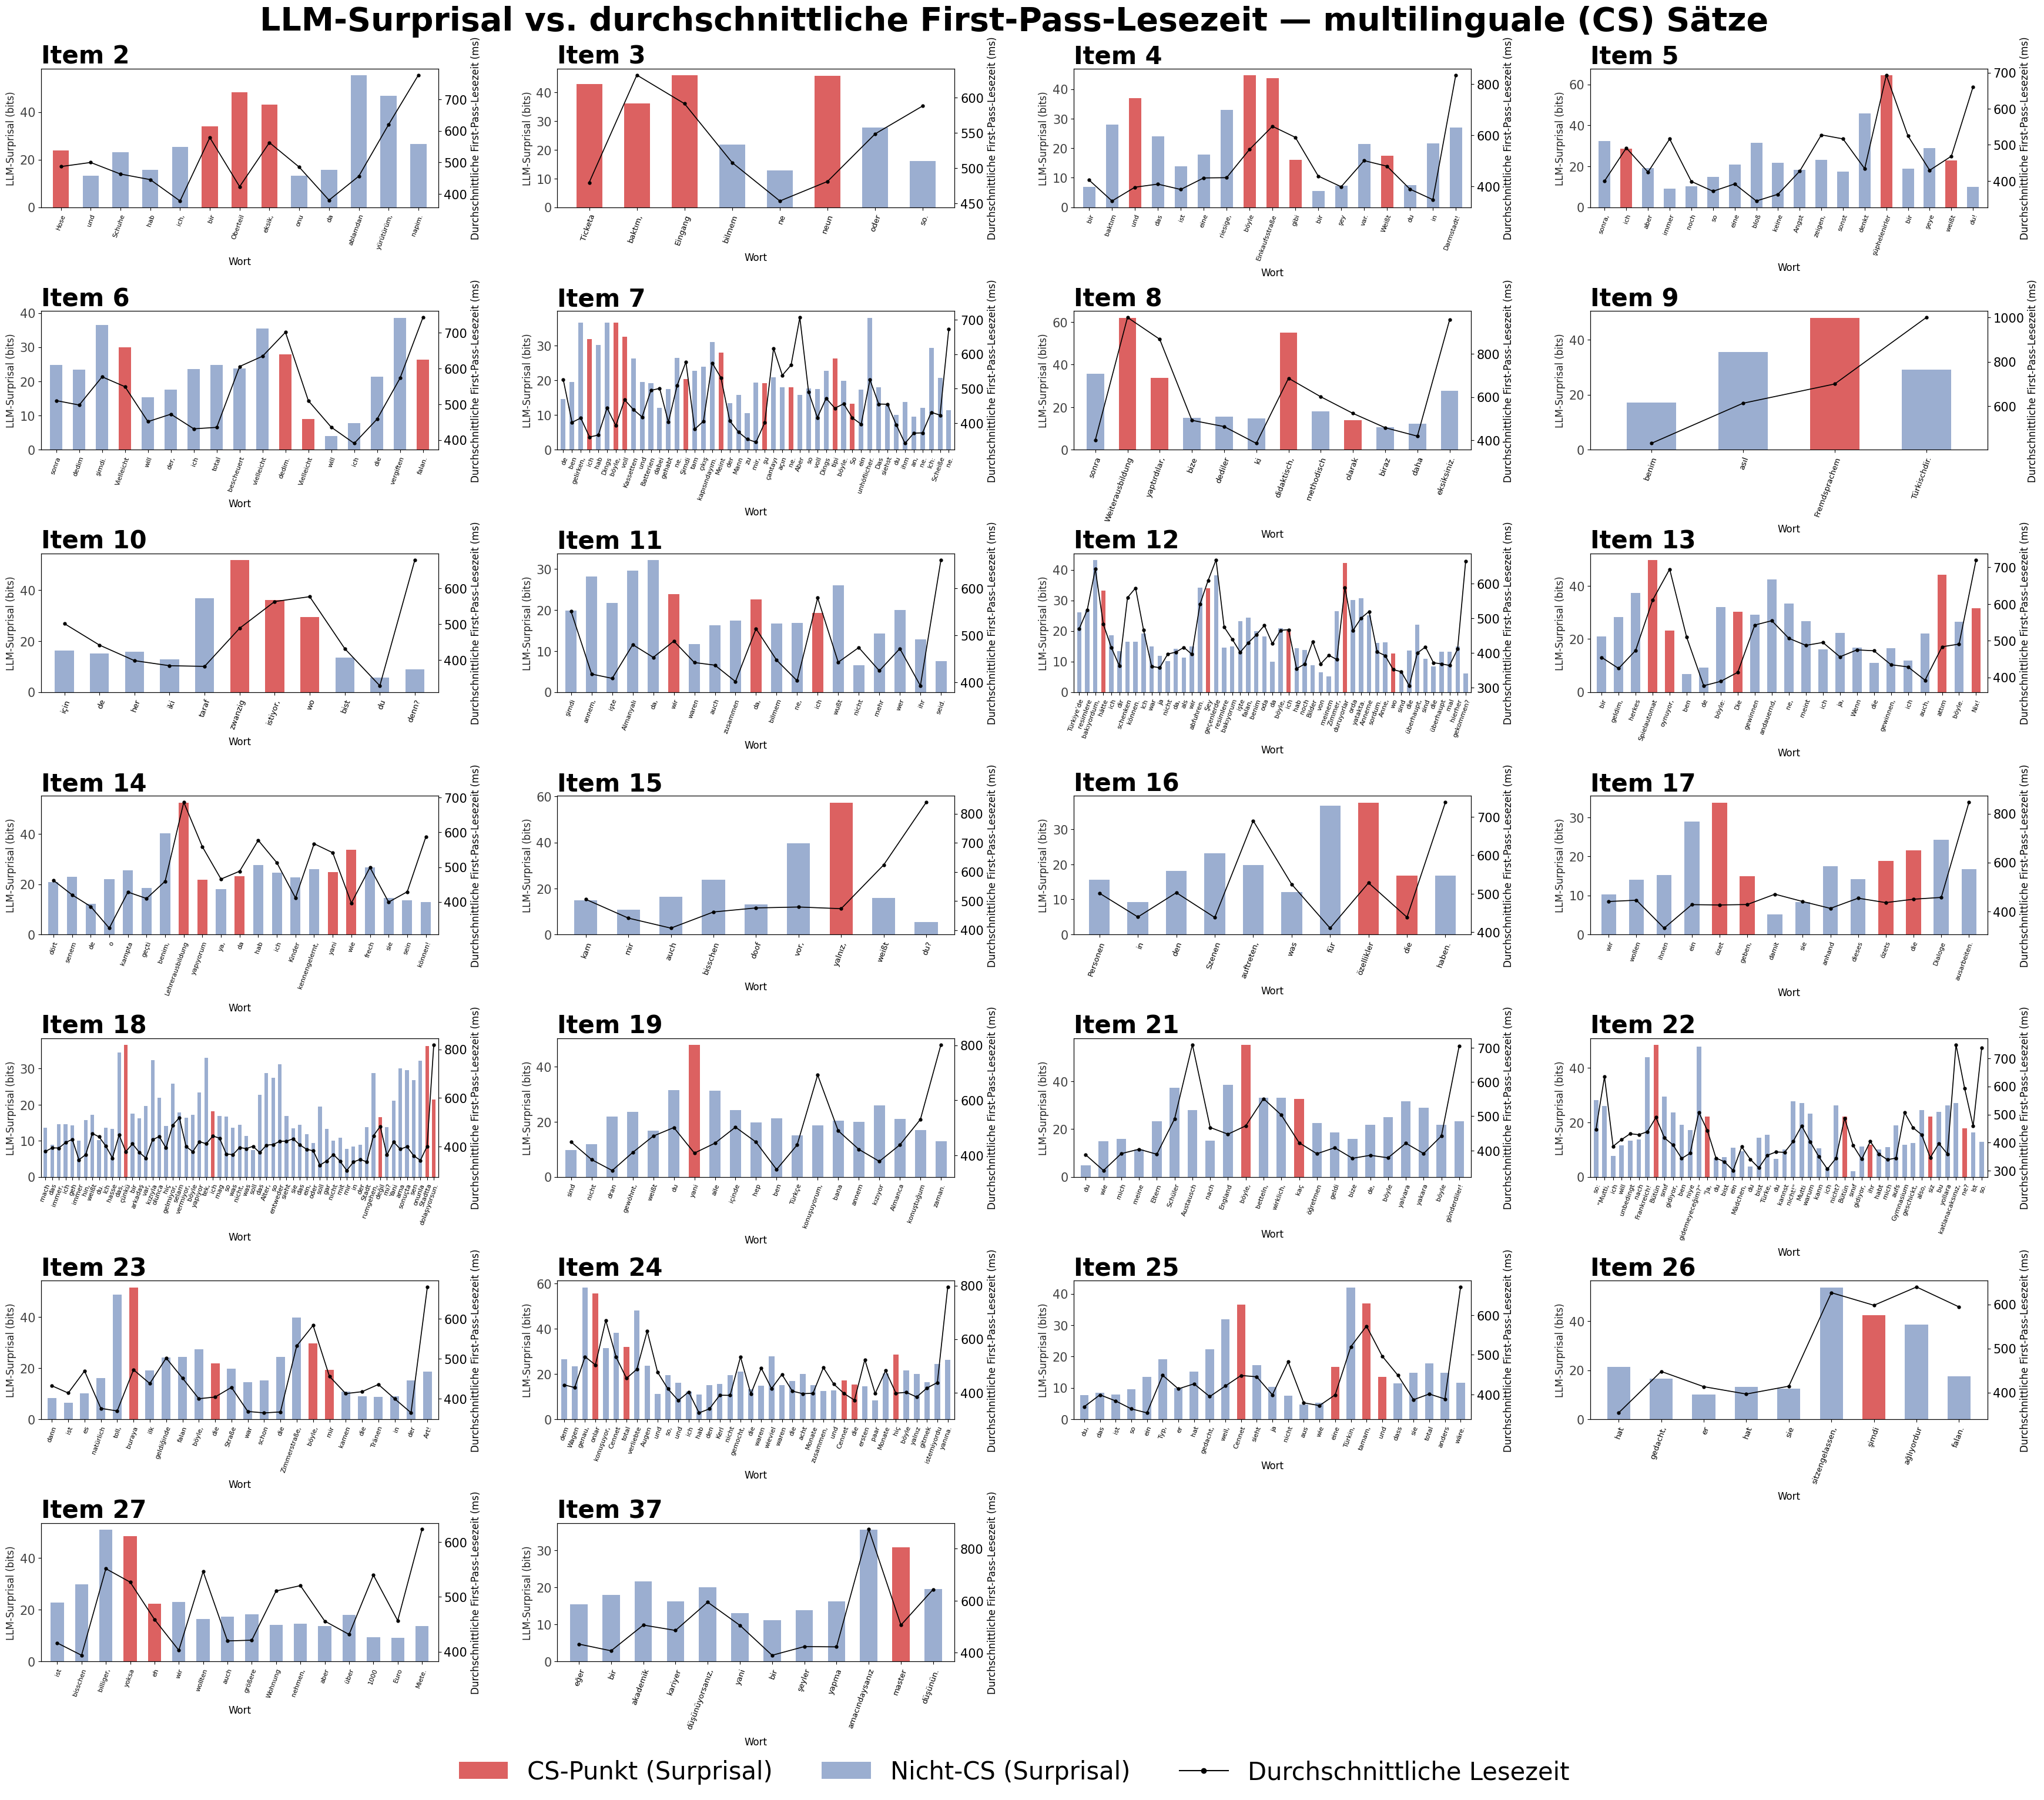

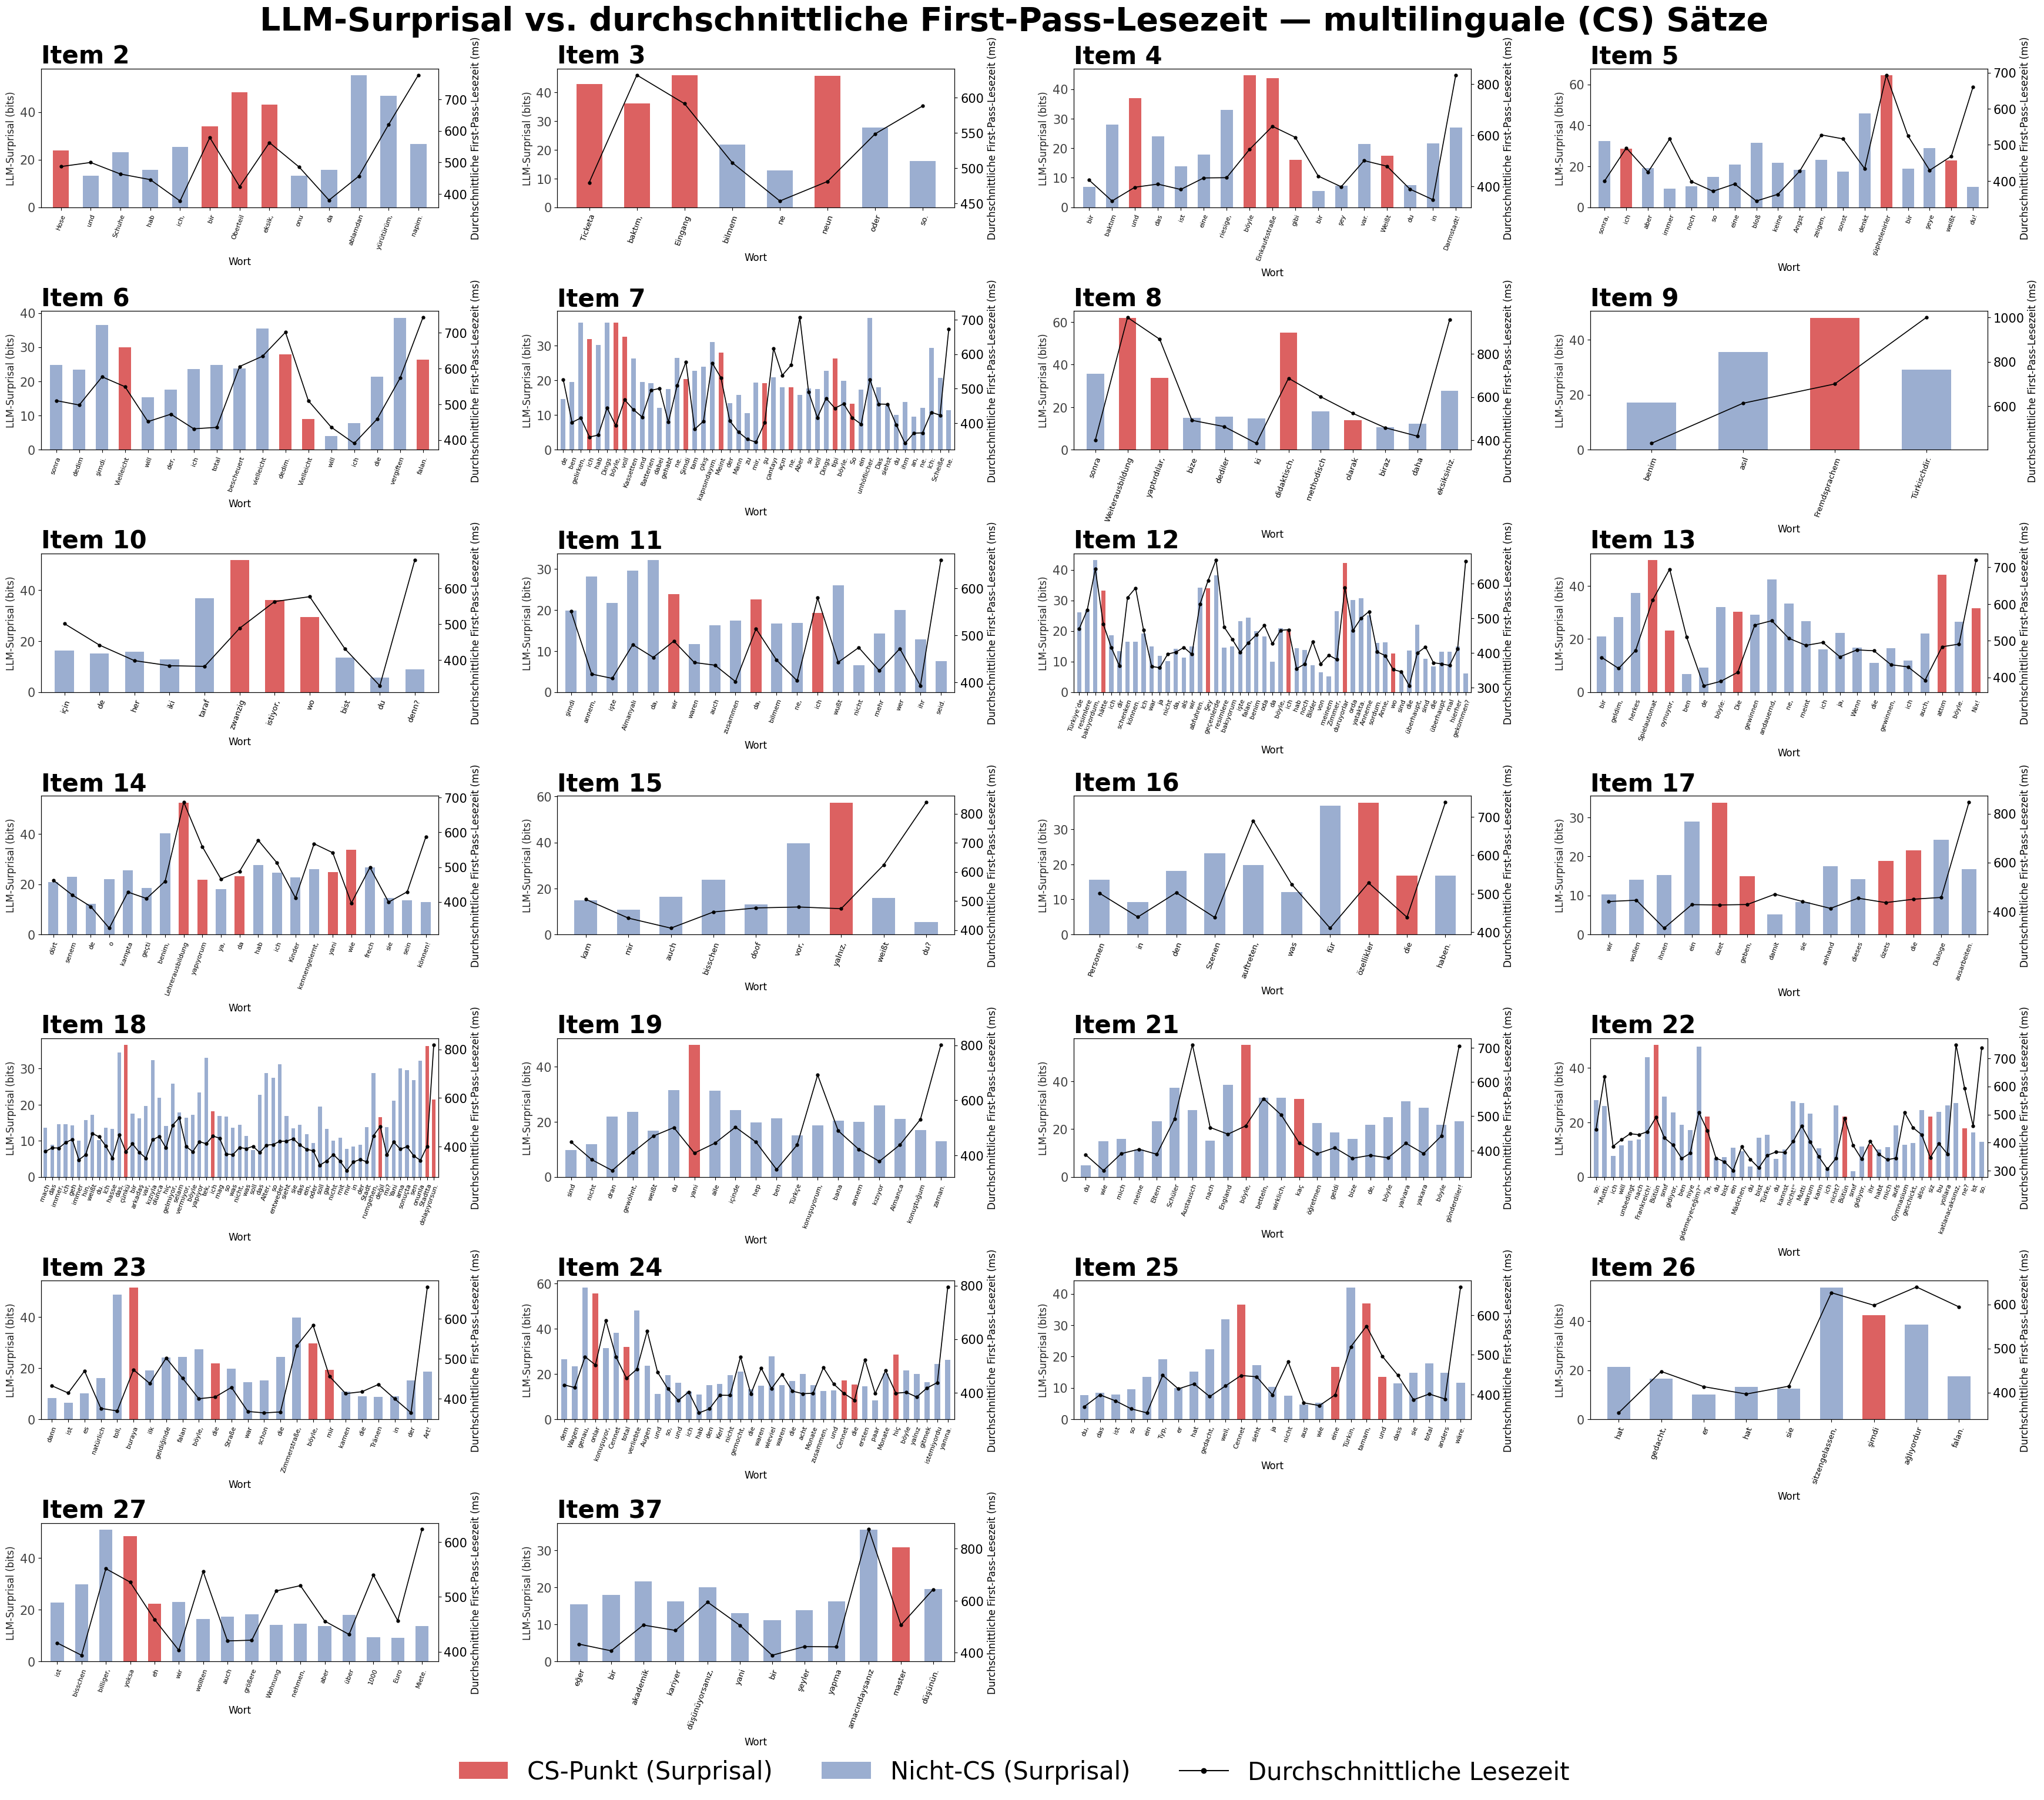

In [ ]:
"""
Übersichtsraster: monolinguale und multilinguale Sätze getrennt
===============================================================

Wiederholt die Einzelsatz-Grafik (Surprisal als Balken, durchschnittliche First-Pass-
Lesezeit als Linie, CS-Punkte hervorgehoben) verkleinert in einem Raster.
Es entstehen zwei Abbildungen: eine für die monolingualen und eine für die
multilingualen (Code-Switching-)Sätze.

Eingabe : Bspr_result/main_analysis_with_surprisal_filtered.csv, word_cs.xlsx
Ausgabe : Bspr_result/monolingual_sentences_grid.png
          Bspr_result/multilingual_sentences_grid.png
"""

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

IN_PATH = Path("Bspr_result/main_analysis_with_surprisal_filtered.csv")
CS_PATH = Path("word_cs.xlsx")
OUT_DIR = Path("Bspr_result")
OUT_DIR.mkdir(parents=True, exist_ok=True)

FIRST_ITEM_ORDER = 2

df = pd.read_csv(IN_PATH)

# Hinweis: experimental_condition (aus dem PCIbex-Rohlog) enthält zwei bekannte
# Fehlkodierungen (item_order 20 und 37) – dort passt das Design-Label nicht zum
# tatsächlichen sprachlichen Inhalt. Sentence-Type aus word_cs.xlsx ist manuell
# geprüft und wird deshalb für die Aufteilung mono-/multilingual verwendet.
cs_xlsx = pd.read_excel(CS_PATH)
sentence_order = cs_xlsx["Sentence"].drop_duplicates().tolist()
item_to_sentence_type = {
    FIRST_ITEM_ORDER + i: cs_xlsx.loc[cs_xlsx["Sentence"] == s, "Sentence-Type"].iloc[0]
    for i, s in enumerate(sentence_order)
}
df["sentence_type"] = df["item_order"].map(item_to_sentence_type)

word_level = (
    df.groupby(["item_order", "word_position", "word", "cs_point", "sentence_type"], sort=False)
    .agg(surprisal=("surprisal_raw", "first"),
         mean_rt=("first_pass_reading_time", "mean"))
    .reset_index()
)

LEGEND_ELEMS = [
    Patch(facecolor="#d64545", alpha=0.85, label="CS-Punkt (Surprisal)"),
    Patch(facecolor="#8aa0c8", alpha=0.85, label="Nicht-CS (Surprisal)"),
    Line2D([0], [0], color="black", marker="o", label="Durchschnittliche Lesezeit"),
]


def plot_grid(data, title, out_name, n_cols=4):
    """Zeichnet je Satz ein kleines Diagramm mit dynamischer Wortabstands- und Schriftanpassung."""
    item_orders = sorted(data["item_order"].unique())
    n = len(item_orders)
    n_rows = int(np.ceil(n / n_cols))

    # Breitere Abbildung fuer laengere Saetze im Raster
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 9.0, n_rows * 4.4))
    axes = np.atleast_1d(axes).flatten()

    for ax, item_order in zip(axes, item_orders):
        sub = data[data["item_order"] == item_order].sort_values("word_position")
        n_words = len(sub)

        # Schrittweite vergroessern, um den horizontalen Abstand zwischen den Woertern zu dehnen
        step = 2.4
        x = np.arange(n_words) * step

        colors = ["#d64545" if cs == 1 else "#8aa0c8" for cs in sub["cs_point"]]

        # Balkenbreite proportional zur Schrittweite setzen, damit Luecken sichtbar bleiben
        ax.bar(x, sub["surprisal"], width=1.3, color=colors, alpha=0.85)

        # Dynamische Schriftgroesse: Saetze mit mehr als 12 Woertern erhalten eine leicht kleinere Schrift
        current_font = 8.0 if n_words > 12 else 9.5

        ax.set_xticks(x)
        # 70-Grad-Winkel verhindert horizontales Ueberlappen bei langen Woertern
        ax.set_xticklabels(
            sub["word"],
            rotation=70,
            ha="right",
            rotation_mode="anchor",
            fontsize=current_font,
        )
        ax.tick_params(axis="y", labelsize=15, labelcolor="#444444")
        ax.set_title(f"Item {item_order}", fontsize=30, loc="left", pad=4, weight="bold")

        ax.set_ylabel("LLM-Surprisal (bits)", fontsize=12, color="#222222")
        ax.set_xlabel("Wort", fontsize=12, labelpad=8)

        # Raender links und rechts anpassen, damit aeussere Balken nicht am Achsenrand kleben
        ax.set_xlim(-1.6, (n_words - 1) * step + 1.6)

        # Lesezeitkurve auf denselben gestreckten x-Koordinaten zeichnen
        ax2 = ax.twinx()
        ax2.plot(x, sub["mean_rt"], color="black", marker="o", markersize=3.5, linewidth=1.2)
        ax2.tick_params(axis="y", labelsize=15, labelcolor="#000000")
        ax2.set_ylabel("Durchschnittliche First-Pass-Lesezeit (ms)", fontsize=12, color="#000000")

    # Nicht benoetigte Subplots abschalten
    for ax in axes[n:]:
        ax.axis("off")

    # Gesamttitel
    fig.suptitle(title, fontsize=40, y=0.985, weight="bold")

    # Layout-Abstaende: Ausreichend Platz nach unten fuer die Legende und vertikal zwischen den Zeilen
    plt.subplots_adjust(left=0.04, right=0.96, top=0.95, bottom=0.07, wspace=0.30, hspace=0.75)

    # Vergroesserte Legende unterhalb der Abbildung
    fig.legend(handles=LEGEND_ELEMS, loc="lower center", bbox_to_anchor=(0.5, -0.01),
               ncol=3, fontsize=30, frameon=False)

    #out_path = OUT_DIR / out_name
    #fig.savefig(out_path, dpi=200, bbox_inches="tight")

    out_path = OUT_DIR / out_name.replace(".png", ".pdf")
    fig.savefig(out_path, format="pdf", bbox_inches="tight")
    print(f"Gespeichert: {out_path}  ({n} Sätze)")

    plt.show()

    return fig


# Funktionsaufrufe
plot_grid(
    word_level[word_level["sentence_type"] == "Monolingual"],
    "LLM-Surprisal vs. durchschnittliche First-Pass-Lesezeit — monolinguale Sätze",
    "monolingual_sentences_grid.png"
)

plot_grid(
    word_level[word_level["sentence_type"] == "Multilingual"],
    "LLM-Surprisal vs. durchschnittliche First-Pass-Lesezeit — multilinguale (CS) Sätze",
    "multilingual_sentences_grid.png"
)